# Seq2Seq 带注意力机制的机器翻译

本 Notebook 实现基于 **Bahdanau 加性注意力（Additive Attention）** 的西班牙语→英语 Seq2Seq 神经机器翻译模型。内容涵盖：文本预处理、平行语料 Dataset、分词器、Encoder-Decoder 模型、带掩码的交叉熵训练，以及推理阶段的注意力热力图可视化。


## 一、环境配置与依赖导入

本章节导入深度学习与数据处理所需的核心库，配置 Matplotlib 内联绘图、计算设备（GPU/CPU）以及随机种子，以保证实验结果可复现。


In [1]:
# 导入 matplotlib 主包，并指定常用别名 mpl
# matplotlib：Python 最流行的 2D 绘图库，支持折线图、热力图等多种可视化
import matplotlib as mpl

# 导入 matplotlib 的绘图子模块 pyplot，提供类 MATLAB 风格的 API
# 常用函数：plt.plot()（折线）、plt.imshow()（矩阵热力图）、plt.show()（渲染图像）
import matplotlib.pyplot as plt

# Jupyter 魔法命令 %matplotlib inline
# 作用：在 Notebook 单元格输出区域直接嵌入渲染后的图像，无需调用 plt.show() 手动弹窗
# 注意：必须放在 import matplotlib 之后、首次绘图之前才能生效
%matplotlib inline

# ── 中文字体配置 ──────────────────────────────────────────────────────────────
# Matplotlib 默认字体 DejaVu Sans 不含中文字形，会导致中文标签渲染为方块并报 UserWarning。
# 在 Windows 上优先使用系统内置的微软雅黑（Microsoft YaHei），
# 回退顺序：SimHei（黑体）→ SimSun（宋体）→ DejaVu Sans（英文兜底）。
# rcParams['font.sans-serif'] : list[str]，无衬线字体候选列表，matplotlib 按顺序取第一个可用字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'DejaVu Sans']

# rcParams['axes.unicode_minus'] = False：
# 修复使用中文字体后负号（U+2212）渲染为方块的问题，改为使用 ASCII 连字符 '-' 显示负号
plt.rcParams['axes.unicode_minus'] = False

# 导入 NumPy，数值计算基础库
# 主要用途：多维数组操作、随机种子设置、统计均值（np.mean）等
import numpy as np

# 导入 scikit-learn（sklearn），机器学习工具库
# 本 Notebook 中 train_test_split 等 API 留作备用；主要用途是打印版本信息
import sklearn

# 导入 pandas，表格型数据处理库
# 本 Notebook 主流程未直接依赖 pandas，保留以备扩展分析使用
import pandas as pd

# 导入 os 标准库，用于目录创建（os.mkdir/os.makedirs）与路径拼接（os.path.join）
import os

# 导入 sys 标准库，用于获取当前 Python 解释器的版本信息（sys.version_info）
import sys

# 导入 time 标准库，可用于计算代码段的执行耗时（本 Notebook 留作备用）
import time

# 从 tqdm 库导入 tqdm 类，用于在训练循环中显示进度条
# tqdm(iterable) 包装任意可迭代对象，自动计算剩余时间并在终端/Notebook 中实时更新
from tqdm import tqdm

# 导入 PyTorch 深度学习框架核心包
# torch 提供张量运算、自动微分（autograd）、模型保存（torch.save/load）等基础能力
import torch

# 导入 torch.nn 模块，包含神经网络常用层与容器
# nn.Embedding：词嵌入层；nn.GRU：门控循环单元；nn.Linear：全连接层；nn.Dropout：随机丢弃
import torch.nn as nn

# 导入 torch.nn.functional，提供无状态（无可训练参数）的函数式 API
# F.softmax：归一化概率；F.cross_entropy：交叉熵损失；F.tanh：双曲正切激活
import torch.nn.functional as F

# 打印 Python 版本元组，字段含义：(major, minor, micro, releaselevel, serial)
# 例如：sys.version_info(major=3, minor=10, micro=9, releaselevel='final', serial=0)
print(sys.version_info)

# 遍历各核心依赖库，打印包名与版本号
# module.__name__ 返回包的模块名（str）；module.__version__ 返回版本字符串（str）
# 目的：快速确认当前运行环境与实验文档记录的版本一致，避免 API 变更引发复现失败
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 选择计算设备：优先使用 GPU（cuda:0），无 GPU 时回退到 CPU
# torch.cuda.is_available() → bool：检测系统是否有可用的 CUDA GPU
# torch.device(str)：创建设备对象，后续张量 .to(device) 会自动迁移到该设备
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

# 打印实际选用的 device，训练前务必确认是否为 GPU
print(device)

# 设定全局随机种子，固定后可使权重初始化、数据划分等随机过程完全可复现
seed = 42

# torch.manual_seed(seed)：设置 CPU 端随机数生成器的种子
# 影响：nn.Module 权重随机初始化、Dropout 掩码等依赖 CPU 随机数的操作
torch.manual_seed(seed)

# torch.cuda.manual_seed_all(seed)：为所有 GPU 设备设置随机种子
# 即使当前无 GPU 也可安全调用（函数内部自动检测）
torch.cuda.manual_seed_all(seed)

# np.random.seed(seed)：设置 NumPy 随机数生成器的全局种子
# 影响：np.random.choice（数据集划分）等依赖 NumPy 随机数的操作
np.random.seed(seed)

sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、数据加载

读取西班牙语-英语平行语料（spa.txt），完成文本清洗、缓存与 PyTorch Dataset 构建，为后续分词与模型训练做准备。


### 2.1 文本预处理

将原始句子标准化为小写、分词友好的格式：去除组合重音、在标点两侧插入空格、过滤非法字符。


In [2]:
# unicodedata：Python 标准库，提供 Unicode 字符数据库查询与规范化功能
# 主要用到：unicodedata.normalize(form, s) 和 unicodedata.category(c)
import unicodedata

# re：Python 标准库，提供正则表达式的编译与匹配功能
# 主要用到：re.sub(pattern, repl, string) 做文本替换清洗
import re

# 从 sklearn.model_selection 导入 train_test_split，用于数据集划分（本文件中备用）
from sklearn.model_selection import train_test_split


def unicode_to_ascii(s):
    """
    去除字符串中字母上的组合重音符号，得到"近似 ASCII"的简化文本。

    原理
    ----
    Unicode NFD 规范化会将带重音的预组合字符（如 é = U+00E9）
    拆分为「基字符 + 独立重音码点」两部分（e + U+0301）。
    其中重音码点的 Unicode 通用类别（category）为 'Mn'（非间距标记）。
    过滤掉所有 Mn 类字符后，只保留基字符，即可去除组合重音。

    适用范围
    --------
    仅能去除可分解的组合重音（á→a、ñ→n、é→e 等）；
    ¿、¡ 等非重音类字符不受影响，原样保留。

    参数
    ----
    s : str
        任意 Unicode 字符串，通常为西班牙语原始句子。

    返回
    ----
    str
        去掉组合重音后的字符串。
        示例：'cafe' → 'cafe'，'nino' → 'nino'，'Hola?' → 'Hola?'
    """
    # 步骤 1：对输入字符串 s 执行 NFD（Canonical Decomposition，规范分解）
    # NFD 将「预组合字符」分解为「基字符 + 独立重音码点」
    # 参数说明：
    #   form : str = 'NFD'，规范化形式，常见还有 NFC/NFKC/NFKD
    #   s    : str，待规范化的 Unicode 字符串
    # 返回值：str，分解后的字符串，长度可能增大（一个字符变两个）
    # 示例：'a'(U+00E9) → 'a'(U+0061) + U+0301（组合锐音符）
    normalized = unicodedata.normalize('NFD', s)

    # 步骤 2：遍历 NFD 分解后的每个字符 c（c 类型为 str，长度恒为 1）
    # unicodedata.category(c)：返回字符 c 的 Unicode 通用类别，类型为 str（2 个字母）
    #   'Mn' = Mark, nonspacing（非间距标记）：附着在基字符上的重音/变音符号
    #   'Ll' = Letter, lowercase（小写字母），'Po' = Punctuation, other 等
    # 只保留 category != 'Mn' 的字符（即保留基字符和非重音标点，丢弃重音符号）
    filtered_chars = [c for c in normalized if unicodedata.category(c) != 'Mn']

    # 步骤 3：将过滤后的字符列表无缝拼接为单个字符串并返回
    # ''.join(iterable)：以空字符串为分隔符，将 list[str] 合并为 str
    # 输入示例：['c', 'a', 'f', 'e'] → 'cafe'
    return ''.join(filtered_chars)


def preprocess_sentence(w):
    """
    对单句执行标准化预处理，生成适合按空格分词并构建词表的规范化文本。

    处理流水线
    ----------
    1. 转小写并去除首尾空白（lower + strip）
    2. 调用 unicode_to_ascii 剥离组合重音（cafe → cafe）
    3. 在 ?.!,¿ 等标点前后各插入一个空格（便于将标点作为独立 token）
    4. 将连续多个空白压缩为单个空格
    5. 将所有非 [a-zA-Z?.!,¿] 字符替换为空格（过滤数字、引号、特殊符号等）
    6. 去除首尾多余空白（rstrip + strip）

    参数
    ----
    w : str
        原始句子字符串，可包含 Unicode 西语字符，如 'Puedo tomar prestado este libro?'

    返回
    ----
    str
        清洗后的句子，词与标点之间均以单空格分隔，全部小写。
        示例：'Puedo tomar prestado este libro?' → '¿ puedo tomar prestado este libro ?'
    """
    # 步骤 1：先转小写（lower()）→ 去首尾空白（strip()）→ 去除组合重音（unicode_to_ascii）
    # w.lower()  : str，将所有字母转为小写，统一大小写表示
    # .strip()   : str，去除字符串首尾的所有空白字符（空格、制表符、换行符）
    # unicode_to_ascii()：去除组合重音，结果仍为 str
    w = unicode_to_ascii(w.lower().strip())

    # 步骤 2：在 ?.!,¿ 标点前后各插入一个空格，将其与相邻词分隔为独立 token
    # re.sub(pattern, repl, string)：将 string 中所有匹配 pattern 的子串替换为 repl
    #   pattern : r"([?.!,¿])"，捕获组匹配任意一个目标标点字符
    #   repl    : r" \1 "，在捕获的标点前后各加一个空格（\1 引用第 1 个捕获组）
    # 示例：'book?' → 'book ? '（前后均有空格）
    w = re.sub(r"([?.!,¿])", r" \1 ", w)

    # 步骤 3：将连续的空白字符（含制表符等）压缩为单个空格
    # pattern : r'[" "]+' 匹配一个或多个空白字符（等价于 r'\s+'）
    # repl    : " "，统一替换为单空格，避免词表中出现空 token
    w = re.sub(r'[" "]+', " ", w)

    # 步骤 4：将所有非 [a-zA-Z?.!,¿] 字符替换为空格，过滤数字、引号、特殊符号等
    # pattern : r"[^a-zA-Z?.!,¿]+"，匹配一个或多个不在白名单中的字符
    # repl    : " "，统一用空格占位（不直接删除，避免词语拼接）
    w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)

    # 步骤 5：再次去除首尾空白，得到最终规范化句子
    # rstrip()：去除字符串右端（行尾）的空白字符
    # strip() ：去除首尾两端的空白字符（冗余但更安全）
    w = w.rstrip().strip()

    # 返回清洗后的 str，可直接用 w.split() 按空格分词
    return w


# 定义英语与西班牙语的测试样例句子
# u"..." 前缀（Unicode 字符串字面量）在 Python 3 中与 str 等价，可省略
en_sentence = u"May I borrow this book?"   # 英语原始句，无重音字符
sp_sentence = u"¿Puedo tomar prestado este libro?"  # 西语原始句，含倒问号 ¿

# 演示 unicode_to_ascii 对英语句的处理效果（无重音，基本原样输出）
print("处理前的文本：", unicode_to_ascii(en_sentence))

# 演示 unicode_to_ascii 对西语句的处理效果（¿ 是标点而非重音，原样保留）
print("处理前的文本：", unicode_to_ascii(sp_sentence))

# 演示 preprocess_sentence 对英语句的完整清洗效果
# 输出示例："may i borrow this book ?"（小写，标点前有空格）
print("处理后的文本，以Unicode编码：", preprocess_sentence(en_sentence))

# 演示 preprocess_sentence 对西语句的完整清洗效果
# 输出示例："¿ puedo tomar prestado este libro ?"
print("处理后的文本，以Unicode编码：", preprocess_sentence(sp_sentence))

# 将清洗后的西语句编码为 UTF-8 字节序列（bytes），说明 str 与 bytes 的区别
# str  ：Python 内存中的 Unicode 文本，字符是抽象码点
# bytes：按指定编码（此处 UTF-8）序列化后的字节序列
# ¿（U+00BF）在 UTF-8 中编码为 2 字节 \xc2\xbf，print(bytes) 显示 b'...' 格式
print("处理后的文本，以UTF-8编码：", preprocess_sentence(sp_sentence).encode('utf-8'))

处理前的文本： May I borrow this book?
处理前的文本： ¿Puedo tomar prestado este libro?
处理后的文本，以Unicode编码： may i borrow this book ?
处理后的文本，以Unicode编码： ¿ puedo tomar prestado este libro ?
处理后的文本，以UTF-8编码： b'\xc2\xbf puedo tomar prestado este libro ?'


### 2.2 数据集类 LangPairDataset

从 spa.txt 读取西英平行句对，经 preprocess_sentence 清洗后缓存为 .npy，并按 9:1 随机划分 train/test。


In [3]:
# 导入 pathlib.Path，以面向对象方式操作文件系统路径（比字符串拼接更安全、跨平台）
from pathlib import Path

# 导入 PyTorch Dataset 基类（用于自定义数据集）与 DataLoader（用于批量加载）
from torch.utils.data import Dataset, DataLoader


class LangPairDataset(Dataset):
    """
    西班牙语→英语平行语料的 PyTorch Dataset。

    数据来源：spa.txt，每行格式为「英语\\t西班牙语」（共 118964 条）。
    __getitem__ 返回 (src 西班牙语句, trg 英语句) 的字符串元组。

    类属性（所有实例共享）
    --------------------
    fpath      : Path  原始平行语料文件路径
    cache_path : Path  预处理后的 .npy 缓存文件路径，避免重复解析 txt
    split_index: ndarray[str]  为每条样本随机分配 "train" 或 "test" 标签的数组

    实例属性
    --------
    self.src : ndarray[str]  当前模式（train/test）的西语句子数组
    self.trg : ndarray[str]  当前模式（train/test）的英语句子数组
    """

    # 原始平行语料文件路径，相对于工作目录
    # Path 对象支持 / 拼接、.exists()、.parent 等方法，优于字符串操作
    fpath = Path(r"data/spa.txt")

    # 预处理结果的 .npy 缓存文件路径
    # numpy .npy 格式支持保存 Python dict（通过 allow_pickle=True），适合缓存中间结果
    cache_path = Path(r"data/cache/lang_pair.npy")

    # 为所有 118964 条样本随机分配 "train" / "test" 标签（9:1 比例）
    # np.random.choice(a, size, replace, p)：
    #   a       : array_like，候选元素列表，此处为 ["train", "test"]
    #   replace : bool，True 表示有放回抽样（各条样本独立分配）
    #   p       : array_like，各候选元素的抽取概率，顺序与 a 对应；[0.9, 0.1] 即 90% train
    #   size    : int，抽取次数，等于语料总行数 118964
    # 返回值：ndarray，shape=(118964,)，每个元素为 "train" 或 "test"
    split_index = np.random.choice(
        a=["train", "test"],  # 候选标签："train" 表示训练集，"test" 表示测试集
        replace=True,         # 有放回抽样，使每条样本独立地按概率分配标签
        p=[0.9, 0.1],         # 90% 的样本划入训练集，10% 划入测试集
        size=118964           # 语料总样本数，与 spa.txt 的总行数一致
    )

    def __init__(self, mode="train", cache=False):
        """
        初始化 Dataset，按 mode 筛选对应的 train 或 test 子集。

        参数
        ----
        mode : str
            "train" 或 "test"，与 split_index 中的标签字符串对应。
        cache : bool
            True 时强制从原始 txt 重建缓存（用于数据更新后刷新）；
            False 时优先加载已有 .npy 缓存（首次运行时若缓存不存在则自动构建）。

        副作用
        ------
        构建后 self.src 与 self.trg 为 ndarray[str]，存储当前 mode 的全部句对。
        """
        # 判断是否需要（重新）构建缓存：
        #   条件 1：cache=True，调用方显式要求重建
        #   条件 2：缓存文件尚不存在（如首次运行、.npy 被删除等情况）
        # self.cache_path.exists() : Path.exists() → bool，True 表示路径在磁盘上存在
        if cache or not self.cache_path.exists():
            # 在写入 .npy 前先确保父目录存在，np.save 本身不会自动创建目录
            # Path.parent : Path 属性，返回当前路径的上一级目录（此处为 data/cache/）
            # Path.mkdir(parents, exist_ok)：
            #   parents  : bool，True 时递归创建所有缺失的上级目录（等同 mkdir -p）
            #   exist_ok : bool，True 时若目录已存在不抛出 FileExistsError
            self.cache_path.parent.mkdir(parents=True, exist_ok=True)

            # 以 UTF-8 编码打开原始语料文件（必须指定 encoding='utf8'，否则在 Windows 下可能乱码）
            with open(self.fpath, "r", encoding="utf8") as file:
                # readlines()：一次性读取所有行，返回 list[str]，每个元素末尾含换行符 \n
                lines = file.readlines()

                # 解析平行句对：
                # l.split('\t') → list[str]，按 Tab 分隔，结果如 ['Go.', 'Ve.', '...']
                # preprocess_sentence(w)：清洗每一侧的句子，结果为小写规范化的 str
                # lang_pair 为 list[list[str]]，每个内层列表为 [英语, 西语] 字符串对
                lang_pair = [[preprocess_sentence(w) for w in l.split('\t')] for l in lines]

                # zip(*lang_pair)：转置，将 [[en1,sp1],[en2,sp2],...] 变为 [(en1,en2,...),(sp1,sp2,...)]
                # 左侧赋值 trg（英语目标端），src（西语源端）
                # zip 返回 tuple，需转为 ndarray 才能用布尔数组做 split_index 筛选
                trg, src = zip(*lang_pair)
                trg = np.array(trg)  # ndarray[str]，英语句子数组，shape=(N,)
                src = np.array(src)  # ndarray[str]，西语句子数组，shape=(N,)

                # 打印总样本数与第一条英/西句，用于快速核验读取结果是否正确
                print(len(trg), trg[0])
                print(src[0])

                # 将英/西句子 ndarray 序列化保存到 .npy（trg/src 已在上方转为 ndarray）
                # np.save(file, arr)：以 .npy 格式保存 ndarray 或任意 Python 对象
                # 此处保存的是 dict（非多维 ndarray），numpy 会用 pickle 序列化后
                # 再包进一个 0 维 object 数组（shape=()，仅含 1 个元素）写入 .npy
                # 读取时必须 allow_pickle=True，并用 .item() 取出其中的 dict
                np.save(self.cache_path, {"trg": trg, "src": src})
        else:
            # 从已有 .npy 缓存加载 dict
            # np.load(file, allow_pickle=True)：加载 .npy 文件
            #   allow_pickle=True：允许反序列化 pickle 对象（此处为 dict），否则抛出 ValueError
            # 返回值：0 维 ndarray，dtype=object，shape=()
            #   该 0 维数组并非手写创建，而是 np.save 保存 dict 时的固定包装格式：
            #   保存时 dict 被 pickle 后作为「唯一元素」存入 0 维 object 数组再写入磁盘
            #   若保存的是普通多维数组（如 np.array([1,2,3])），np.load 会直接返回该 ndarray，无需 .item()
            # .item()：从 0 维数组中取出唯一元素，还原为 Python dict
            #   返回类型：dict，键 "trg"/"src" 对应 ndarray[str]
            lang_pair = np.load(self.cache_path, allow_pickle=True).item()
            trg = lang_pair["trg"]  # ndarray[str]，英语句子数组
            src = lang_pair["src"]  # ndarray[str]，西语句子数组

        # 布尔索引筛选：split_index == mode 生成 bool 数组，True 的位置即当前 mode 的样本
        # 结果：self.trg 与 self.src 均为 ndarray[str]，仅包含 train 或 test 子集
        self.trg = trg[self.split_index == mode]
        self.src = src[self.split_index == mode]

    def __getitem__(self, index):
        """
        按索引返回单条样本，供 DataLoader 随机/顺序采样。

        参数
        ----
        index : int
            样本在当前子集中的位置索引（0 到 len-1）。

        返回
        ----
        tuple[str, str]
            (src 西语句, trg 英语句)，两者均为已预处理的字符串。
        """
        # 直接按索引从 numpy 数组中取出对应字符串并封装为元组返回
        return self.src[index], self.trg[index]

    def __len__(self):
        """
        返回当前子集的样本总数，供 DataLoader 计算 epoch 步数。

        返回
        ----
        int
            当前 mode（train 或 test）下的样本数量。
        """
        # len(ndarray) 返回第 0 维的大小，即样本数
        return len(self.src)


# 实例化训练集：mode="train"，使用 split_index 中标记为 "train" 的约 90% 样本
train_ds = LangPairDataset("train")

# 实例化测试集：mode="test"，使用 split_index 中标记为 "test" 的约 10% 样本
test_ds = LangPairDataset("test")

In [4]:
# 取训练集的最后一条样本（train_ds[-1]），返回 (src 西语, trg 英语) 字符串元组
# Python 支持负索引，-1 表示最后一个元素
# format(*pair)：将二元组 (src, trg) 解包（*），依次填入 {} 占位符
print("source: {}\ntarget: {}".format(*train_ds[-1]))

source: si quieres sonar como un hablante nativo , debes estar dispuesto a practicar diciendo la misma frase una y otra vez de la misma manera en que un musico de banjo practica el mismo fraseo una y otra vez hasta que lo puedan tocar correctamente y en el tiempo esperado .
target: if you want to sound like a native speaker , you must be willing to practice saying the same sentence over and over in the same way that banjo players practice the same phrase over and over until they can play it correctly and at the desired tempo .


### 2.3 分词器 Tokenizer

Encoder 与 Decoder 词嵌入不共享，分别构建 src（西语）/ trg（英语）词表，并提供 encode/decode 接口。


In [5]:
# 导入 Counter，用于统计可迭代对象中各元素的出现频次
# Counter 是 dict 的子类，Counter({token: count, ...})，支持 .items() / .most_common() 等方法
# 输入要求：任意可迭代对象（list / tuple / str 等），元素须可哈希（hashable，如 str、int）
#   - 传入 list[str]（词列表）时：统计每个词的出现次数，空格不会作为 token 被统计
#   - 若直接传入 str：会按字符逐个统计（含空格），与本 notebook 的按词统计不同
# 排序说明：Counter 本身不保证按词频降序；.items() 按元素在输入中首次出现的顺序遍历
#   - 需要按词频从高到低排列时，应使用 .most_common()，返回 list[tuple[token, count]]
from collections import Counter


def get_word_idx(ds, mode="src", threshold=2):
    """
    遍历 Dataset，统计词频并构建 word2idx / idx2word 双向映射词表。

    特殊符号（索引 0-3）固定为：
        0: [PAD]  填充符，用于对齐变长序列
        1: [BOS]  句首符号 Begin-of-Sequence，作为 Decoder 的起始输入
        2: [UNK]  未登录词，处理词表外（OOV）的词
        3: [EOS]  句尾符号 End-of-Sequence，表示生成结束

    参数
    ----
    ds : LangPairDataset
        训练集实例，可迭代，每次 yield (src 西语, trg 英语) 字符串元组。
    mode : str
        "src"：统计源语言（西语）词频；"trg"：统计目标语言（英语）词频。
    threshold : int
        词频下限（函数内部强制重置为 1，即收录所有出现过的词）。

    返回
    ----
    tuple[dict[str, int], dict[int, str]]
        (word2idx, idx2word)
        - word2idx：str → int，词到索引的映射，含特殊符号
        - idx2word：int → str，索引到词的映射，与 word2idx 互逆
    """
    # 初始化词表，将 4 个特殊 token 预先以固定索引（0-3）写入
    # [PAD]=0：填充符，将短句补齐到 batch 内最长句的长度
    # [BOS]=1：Decoder 起始输入，告知模型"开始生成"
    # [UNK]=2：未登录词替代符，避免 KeyError
    # [EOS]=3：生成终止信号，贪心解码时遇到此 token 停止
    word2idx = {
        "[PAD]": 0,
        "[BOS]": 1,
        "[UNK]": 2,
        "[EOS]": 3,
    }

    # 由 word2idx 反向构建 idx2word：遍历所有 (词, 索引) 键值对，交换后存入新 dict
    # idx2word : dict[int, str]，索引到词的映射，供解码时将 id 还原为可读文本
    idx2word = {value: key for key, value in word2idx.items()}

    # 下一个可分配的普通词索引（特殊符号占用 0-3，普通词从 4 开始）
    # index 随词表扩充而递增
    index = len(idx2word)

    # 强制将词频阈值设为 1，即出现至少 1 次的词均收录入词表
    # 注意：函数签名中 threshold=2 为默认值，但实际上此处覆盖为 1（保留更多低频词）
    threshold = 1

    # 从数据集中提取指定语言侧的所有句子，拼接后按空格切分得到词列表
    # [pair[0 if mode=="src" else 1] for pair in ds]：
    #   - pair[0]：src 西语句子；pair[1]：trg 英语句子（str 类型）
    #   - 列表推导遍历整个 ds，提取所有句子组成 list[str]
    # " ".join(...)：用空格将所有句子连接为一个大字符串
    # .split()：按空格拆分为 list[str]，即词的一维列表
    word_list = " ".join([pair[0 if mode == "src" else 1] for pair in ds]).split()

    # Counter(word_list)：对词列表做词频统计
    # 输入类型：list[str]，由上方 .split() 得到；每个元素是一个词（token），空格仅作分隔符
    # 返回类型：Counter（dict 子类），键为词、值为出现次数，如 Counter({'el': 5000, 'de': 4800, ...})
    # 注意：Counter 不会自动按词频降序排列；下方 .items() 按词在 word_list 中首次出现的顺序遍历
    # 若需按词频降序查看，可调用 counter.most_common()，返回 [(token, count), ...] 且 count 从高到低
    counter = Counter(word_list)

    # 遍历 (token, count) 键值对（非词频降序），将满足词频阈值的词加入词表
    for token, count in counter.items():
        # count >= threshold（此处 threshold=1）：几乎所有词都满足
        if count >= threshold:
            # 将词写入 word2idx，分配当前最大索引
            word2idx[token] = index
            # 同步写入 idx2word，保持双向映射一致
            idx2word[index] = token
            # 索引递增，为下一个新词预留位置
            index += 1

    # 返回双向映射元组，供 Tokenizer 初始化使用
    return word2idx, idx2word


# 为西语源端（src）构建词表，遍历 train_ds 中的所有西语句子
# src_word2idx : dict[str, int]，西语词 → 整数 id
# src_idx2word : dict[int, str]，整数 id → 西语词
src_word2idx, src_idx2word = get_word_idx(train_ds, "src")

# 为英语目标端（trg）构建词表，遍历 train_ds 中的所有英语句子
# trg_word2idx : dict[str, int]，英语词 → 整数 id
# trg_idx2word : dict[int, str]，整数 id → 英语词
trg_word2idx, trg_idx2word = get_word_idx(train_ds, "trg")

In [6]:
class Tokenizer:
    """
    词表编解码器：在分词后的文本列表与定长整数张量之间双向转换。

    encode：将 list[list[str]] → Tensor[B, T]（含 BOS/EOS/PAD/UNK）
    decode：将 list[list[int]] → list[str]（可选去除特殊符号）
    """

    def __init__(self, word2idx, idx2word, max_length=float('inf'),
                 pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        """
        初始化分词器，绑定词表与各特殊符号的索引。

        参数
        ----
        word2idx   : dict[str, int]  词 → 索引映射（含特殊符号）
        idx2word   : dict[int, str]  索引 → 词映射（与 word2idx 互逆）
        max_length : float | int     单句编码后的最大 token 数（含 BOS/EOS）；
                                     默认 float('inf')，即不截断，保留句子完整长度；
                                     encode() 内通过 min(max_length, batch实际最长长度)
                                     计算本 batch 的真实序列长度，float('inf') 时该 min
                                     始终返回 batch 实际最长长度，因此不会引发类型错误
        pad_idx    : int             填充符 [PAD] 的索引；默认 0
        bos_idx    : int             句首符 [BOS] 的索引；默认 1
        eos_idx    : int             句尾符 [EOS] 的索引；默认 3
        unk_idx    : int             未登录词 [UNK] 的索引；默认 2
        """
        # 将词表和超参数保存为实例属性，供 encode/decode 方法使用
        self.word2idx = word2idx    # dict[str, int]，词 → id
        self.idx2word = idx2word    # dict[int, str]，id → 词
        self.max_length = max_length  # float | int，序列长度上限；inf 表示不截断
        self.pad_idx = pad_idx      # int，PAD 符号索引
        self.bos_idx = bos_idx      # int，BOS 符号索引
        self.eos_idx = eos_idx      # int，EOS 符号索引
        self.unk_idx = unk_idx      # int，UNK 符号索引

    def encode(self, text_list, padding_first=False,
               add_bos=True, add_eos=True, return_mask=False):
        """
        将一个 batch 的分词句子编码为定长整数张量。

        参数
        ----
        text_list     : list[list[str]]
            外层为 batch，内层为一条句子的 token 列表。
            示例：[["hello", "world"], ["this", "is", "a", "test"]]
        padding_first : bool
            True：PAD 补在句子左侧（适合 Encoder，使真实内容靠右）；
            False：PAD 补在句子右侧（适合 Decoder，使真实内容靠左）。
        add_bos       : bool  True 时在序列开头插入 [BOS]；默认 True
        add_eos       : bool  True 时在序列末尾追加 [EOS]；默认 True
        return_mask   : bool
            True 时同时返回 padding mask（1=PAD，0=有效 token）；
            False 时只返回 input_ids。

        返回
        ----
        若 return_mask=False：
            input_ids : Tensor[B, T]，int64，编码后的 id 张量
        若 return_mask=True：
            (input_ids, masks)
            - input_ids : Tensor[B, T]，int64
            - masks     : Tensor[B, T]，int64，1 表示 PAD 位置
        """
        # 计算本 batch 实际使用的最大长度：
        #   max([len(text) for text in text_list])：本 batch 中最长句子的 token 数
        #   + add_bos + add_eos：为 BOS 和 EOS 各预留 1 个位置（bool 可直接参与加法）
        #   min(..., self.max_length)：不超过初始化时指定的硬上限；
        #     当 self.max_length = float('inf') 时，min 始终返回 batch 的实际最长长度（有限整数），
        #     因此不触发任何截断，后续切片与乘法运算均以该有限整数为准，不存在类型问题
        max_length = min(
            self.max_length,
            add_eos + add_bos + max([len(text) for text in text_list])
        )

        # 用于存放本 batch 中每条句子的 id 列表
        indices_list = []

        for text in text_list:
            # 将每个词映射为整数 id；未登录词（词表中不存在的词）使用 unk_idx 替代
            # text[:max_length - add_bos - add_eos]：为 BOS/EOS 预留位置后取词
            #   当 self.max_length = float('inf')（默认）时，局部 max_length
            #   = add_bos + add_eos + batch内最长句长度，切片上限 ≥ 当前句长度，
            #   因此不会截断任何词，句子得到完整保留；
            #   仅当调用方传入有限整数 max_length 且句子超长时，切片才真正起到截断作用
            # dict.get(key, default)：安全取值，键不存在时返回 default（即 unk_idx）
            indices = [
                self.word2idx.get(word, self.unk_idx)
                for word in text[:max_length - add_bos - add_eos]
            ]

            # 若需要 BOS，在序列最前面插入 bos_idx（列表拼接实现）
            if add_bos:
                indices = [self.bos_idx] + indices

            # 若需要 EOS，在序列最末尾追加 eos_idx
            if add_eos:
                indices = indices + [self.eos_idx]

            # 使用 pad_idx 将序列填充到 max_length（不足则补 PAD，超出已在截断步骤处理）
            if padding_first:
                # 左侧填充：先补 (max_length - 当前长度) 个 PAD，再接原始序列
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                # 右侧填充：先接原始序列，再补 (max_length - 当前长度) 个 PAD
                indices = indices + [self.pad_idx] * (max_length - len(indices))

            # 将当前句子的 id 列表加入 batch 列表
            indices_list.append(indices)

        # torch.tensor(indices_list)：将 list[list[int]] 转为 Tensor，形状 [B, T]，默认 int64
        input_ids = torch.tensor(indices_list)

        # 生成 padding mask：PAD 位置（input_ids == pad_idx）为 True，转 int64 后为 1
        # 形状：[B, T]，int64；有效 token 处为 0，PAD 处为 1
        # 用途：在注意力计算中将 PAD 位置的分数置为极小值（-inf），使其 softmax 后权重≈0
        masks = (input_ids == self.pad_idx).to(dtype=torch.int64)

        # 根据 return_mask 决定返回值：仅 id 张量 或 (id 张量, mask 张量) 元组
        return input_ids if not return_mask else (input_ids, masks)

    def decode(self, indices_list, remove_bos=True,
               remove_eos=True, remove_pad=True, split=False):
        """
        将整数 id 序列解码回可读文本。

        参数
        ----
        indices_list : list[list[int]]
            一个 batch 的 id 序列（通常来自 Tensor.tolist()）。
        remove_bos   : bool  True 时跳过 [BOS] token；默认 True
        remove_eos   : bool  True 时遇到 [EOS] 立即停止解码（截断后续 id）；默认 True
        remove_pad   : bool  True 时遇到 [PAD] 立即停止解码；默认 True
        split        : bool
            True：返回 list[str]（词列表，保留分词结果）；
            False：返回空格拼接的完整句子字符串（str）。

        返回
        ----
        list[str] 或 list[list[str]]
            每条样本解码后的文本（或词列表）。
        """
        # 存放所有样本的解码结果
        text_list = []

        for indices in indices_list:
            # 当前句子的词列表，逐步追加有效 token
            text = []

            for index in indices:
                # idx2word.get(index, "[UNK]")：id → 词；id 不在词表中时返回 "[UNK]"
                word = self.idx2word.get(index, "[UNK]")

                # 若设置 remove_bos 且当前词为 BOS，则跳过（continue 进入下一个 id）
                if remove_bos and word == "[BOS]":
                    continue

                # 若设置 remove_eos 且当前词为 EOS，则停止解码（break 退出内层 for 循环）
                # 说明：EOS 之后通常是 PAD 或无意义内容，无需继续解码
                if remove_eos and word == "[EOS]":
                    break

                # 若设置 remove_pad 且当前词为 PAD，则停止解码
                if remove_pad and word == "[PAD]":
                    break

                # 将有效词追加到当前句子的词列表
                text.append(word)

            # 根据 split 参数决定输出格式：
            #   split=False：" ".join(text) 将词列表拼接为空格分隔的字符串
            #   split=True：直接返回词列表 text，保留分词结果
            text_list.append(" ".join(text) if not split else text)

        return text_list


# 为西语源端实例化 Tokenizer，绑定 src_word2idx 与 src_idx2word
# src_tokenizer 将在 collate_fct 中对 Encoder 的输入句子进行编码
src_tokenizer = Tokenizer(word2idx=src_word2idx, idx2word=src_idx2word)

# 为英语目标端实例化 Tokenizer，绑定 trg_word2idx 与 trg_idx2word
# trg_tokenizer 将在 collate_fct 中对 Decoder 的输入/标签进行编码，以及推理时解码输出
trg_tokenizer = Tokenizer(word2idx=trg_word2idx, idx2word=trg_idx2word)

# 演示：对两条不同长度的英语句子进行编码（加 BOS，不加 EOS）
# 结果形状：[2, 3]；其中短句右侧补 PAD
trg_tokenizer.encode([["hello"], ["hello", "world"]], add_bos=True, add_eos=False)

# 构造三条分词后的英语句子作为 batch 输入（list[list[str]]）
raw_text = [
    "hello world".split(),                       # 2 个词
    "tokenize text datas with batch".split(),     # 5 个词（含未登录词 datas）
    "this is a test".split(),                     # 4 个词
]

# 编码：不加 BOS，加 EOS，PAD 补在右侧（句尾）
# 返回 Tensor[3, T]，T 为本 batch 中最长序列（5词+1EOS=6）的长度
indices = trg_tokenizer.encode(raw_text, padding_first=False, add_bos=False, add_eos=True)

# 解码回文本（保留所有特殊符号 BOS/EOS/PAD，便于与编码结果对照验证）
decode_text = trg_tokenizer.decode(
    indices.tolist(), remove_bos=False, remove_eos=False, remove_pad=False
)

# 打印原始词列表、编码后的整数张量、解码后的文本，逐条对照
print("raw text")
for raw in raw_text:
    print(raw)
print("indices")
for index in indices:
    print(index)
print("decode text")
for decode in decode_text:
    print(decode)

raw text
['hello', 'world']
['tokenize', 'text', 'datas', 'with', 'batch']
['this', 'is', 'a', 'test']
indices
tensor([  17, 3224,    3,    0,    0,    0])
tensor([   2, 3870,    2,  538,    2,    3])
tensor([ 121,  233,  107, 1262,    3,    0])
decode text
hello world [EOS] [PAD] [PAD] [PAD]
[UNK] text [UNK] with [UNK] [EOS]
this is a test [EOS] [PAD]


### 2.4 DataLoader 批处理

定义 collate_fn 将变长句对打包为固定形状张量，并搬运到 GPU/CPU。


In [7]:
def collate_fct(batch):
    """
    DataLoader 的自定义 collate 函数：将一批字符串句对转换为模型所需的张量 dict。

    DataLoader 每次从 Dataset 中采样 batch_size 条样本，调用此函数将它们整合成一个 batch。
    函数负责：分词 → 编码（含 BOS/EOS/PAD）→ 迁移到 GPU/CPU。

    参数
    ----
    batch : list[tuple[str, str]]
        DataLoader 采样的一个 mini-batch，每个元素为 (西语句, 英语句) 字符串元组。

    返回
    ----
    dict，包含以下键值对，所有张量已移至 device（GPU 或 CPU）：

    张量形状符号说明（下文 Tensor[B, T_*] 中各字母的含义）
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    B     : int，Batch Size（批次大小），一次送入模型的句子条数，即 mini-batch 大小
    T     : int，Time steps（时间步数）/ 序列长度，张量沿 token 轴的列数；
            在 RNN/Seq2Seq 中习惯用 T 表示「按时间步展开」的序列维度（类比图像中的 H、W）
    T_src : int，本 batch 内源语言（西语）序列的统一长度；短句经左填充（PAD）后与 batch 内
            最长源句对齐，故 T_src = 该 batch 最长源句的 token 数（含 BOS/EOS）
    T_tgt : int，本 batch 内目标语言（英语）序列的统一长度；短句经右填充后与 batch 内
            最长目标句对齐，故 T_tgt = 该 batch 最长目标句的 token 数（含 BOS 或 EOS）
    注意：T_src、T_tgt 随每个 batch 动态变化，并非全局固定常数；例如 B=4、T_src=12 时，
          encoder_inputs 形状为 (4, 12)，即 4 行源句、每行 12 个 token id。

    各字段：
        encoder_inputs      : Tensor[B, T_src]  源句 token id，含 BOS/EOS；短句在句首左填充 PAD
        encoder_inputs_mask : Tensor[B, T_src]  编码器 PAD 掩码；0=有效 token，1=左填充 PAD；
                                                  传入 BahdanauAttention，将 PAD 处 score 压为 -∞，
                                                  softmax 后权重趋近 0，屏蔽 PAD 对上下文向量的污染
        decoder_inputs      : Tensor[B, T_tgt]  Teacher Forcing 输入，以 BOS 开头、无 EOS；
                                                  短句在句尾右填充 PAD，但无需掩码（原因见下）
        decoder_labels      : Tensor[B, T_tgt]  预测目标 token id，无 BOS、以 EOS 结尾；
                                                  与 decoder_inputs 错位一步（输入 t → 预测 t+1）
        decoder_labels_mask : Tensor[B, T_tgt]  解码器标签 PAD 掩码；0=有效 token，1=右填充 PAD；
                                                  传入损失函数，将 PAD 步交叉熵置 0，
                                                  使 loss 只对真实 token 和 EOS 步的预测误差求均值

    掩码设计说明
    ~~~~~~~~~~~~
    本函数共产生两个掩码张量，各自服务于前向传播的不同阶段：

    ① encoder_inputs_mask —— 编码器端 PAD 掩码（屏蔽注意力中的无效位置）
       源句采用左填充：短于 T_src 的句子在句首补 PAD，真实 token 靠右排列。
       Bahdanau 注意力对全部 T_src 个编码器隐状态打分；若不加掩码，左侧 PAD
       位置的隐状态也会分到非零注意力权重，上下文向量（context vector）将包含
       无意义的 PAD 信息。encoder_inputs_mask 将这些位置标记为 1，注意力模块
       把对应 score 置为 -∞，softmax 后权重趋近 0，彻底屏蔽 PAD 的干扰。

    ② decoder_labels_mask —— 解码器端标签 PAD 掩码（剔除 loss 中的无效步）
       目标句采用右填充：短于 T_tgt 的句子在句尾补 PAD。损失函数对 batch 内全部
       T_tgt 步逐位计算交叉熵后求均值；若不掩盖 PAD 步，模型被迫"学习预测 PAD"，
       且 loss 均值被无意义步稀释，导致梯度失真。decoder_labels_mask 将 PAD 步
       标记为 1，损失函数将对应步的交叉熵置 0，只对真实 token 和 EOS 步求均值。

    ③ 为何 decoder_inputs 不生成掩码
       decoder_inputs 是 Teacher Forcing 的逐步输入，只在每个解码时间步向 GRU
       提供"上一个真实 token"。即使句尾 PAD token 也会经过 Embedding 和 GRU，
       但该步对应的标签同为 PAD，decoder_labels_mask 已在 loss 层将其置 0——
       PAD 步不产生梯度，对参数更新无影响。Seq2Seq.forward 也没有 decoder 输入
       侧掩码参数，故无需为 decoder_inputs 生成或传递掩码。
    """
    # 将 batch 中每条样本的西语句子按空格分词，得到 list[list[str]]
    # pair[0] 为西语句（src），pair[1] 为英语句（trg）
    src_words = [pair[0].split() for pair in batch]

    # 将 batch 中每条样本的英语句子按空格分词，得到 list[list[str]]
    trg_words = [pair[1].split() for pair in batch]

    # 编码 Encoder 输入序列（西语源句）：
    #   padding_first=True：PAD 补在左侧（句首），真实内容靠右，符合 GRU 阅读顺序习惯
    #   add_bos=True, add_eos=True：在真实内容前后分别插入 BOS 和 EOS
    #   return_mask=True：同时返回 PAD 掩码（供 BahdanauAttention 屏蔽 PAD 位置）
    # encoder_inputs      : Tensor[B, T_src]，int64
    # encoder_inputs_mask : Tensor[B, T_src]，int64，1=PAD
    encoder_inputs, encoder_inputs_mask = src_tokenizer.encode(
        src_words, padding_first=True, add_bos=True, add_eos=True, return_mask=True
    )

    # 编码 Decoder 输入序列（英语目标句，Teacher Forcing 用）：
    #   padding_first=False：PAD 补在右侧（句尾）
    #   add_bos=True：以 BOS 作为第一个输入 token（"开始生成"信号）
    #   add_eos=False：不追加 EOS（Decoder 输入不需要看到自身的 EOS）
    #   return_mask=False：decoder_inputs 无需 PAD 掩码，理由：
    #     · decoder_inputs 的唯一消费方是解码器 GRU（Teacher Forcing 逐步输入）；
    #       Seq2Seq.forward 不接收 decoder 输入侧掩码参数，掩码无处传递
    #     · 句尾 PAD 步虽会经过 Embedding / GRU，但对应标签同为 PAD；
    #       decoder_labels_mask 已在 loss 层将该步交叉熵置 0，不产生梯度
    #     · 时序对齐示意：decoder_inputs  = [BOS, w1, …, wN,  PAD, …]
    #                     decoder_labels  = [ w1, w2, …, wN, EOS, PAD, …]
    #       第 i 步以 inputs[:, i] 作为输入，预测 labels[:, i]；PAD 步由掩码剔除
    # decoder_inputs : Tensor[B, T_tgt]，int64；序列为 [BOS, w1, w2, ..., wN, PAD, ...]
    decoder_inputs = trg_tokenizer.encode(
        trg_words, padding_first=False, add_bos=True, add_eos=False, return_mask=False,
    )

    # 编码 Decoder 标签序列（用于计算交叉熵损失的目标 id）：
    #   add_bos=False：标签不含 BOS（从第 1 个真实词开始）
    #   add_eos=True ：标签末尾追加 EOS（告知模型何时停止生成）
    # decoder_labels      : Tensor[B, T_tgt]，int64；序列为 [w1, w2, ..., wN, EOS]
    # decoder_labels_mask : Tensor[B, T_tgt]，int64；1=PAD 位置（不参与 loss 均值计算）
    decoder_labels, decoder_labels_mask = trg_tokenizer.encode(
        trg_words, padding_first=False, add_bos=False, add_eos=True, return_mask=True
    )

    # 将所有张量移至目标设备（GPU 或 CPU），并封装为 dict 返回给训练循环
    # Tensor.to(device=device)：将张量迁移到指定设备，返回迁移后的新张量
    return {
        "encoder_inputs": encoder_inputs.to(device=device),
        "encoder_inputs_mask": encoder_inputs_mask.to(device=device),
        "decoder_inputs": decoder_inputs.to(device=device),
        "decoder_labels": decoder_labels.to(device=device),
        "decoder_labels_mask": decoder_labels_mask.to(device=device),
    }

In [8]:
# 构建用于演示的 DataLoader，参数说明：
#   dataset       : train_ds，数据来源为训练集
#   batch_size    : int=2，每个 batch 包含 2 条样本
#   shuffle       : bool=True，每个 epoch 开始前随机打乱样本顺序（防止模型记住数据顺序）
#   collate_fn    : callable，指定自定义的批整合函数 collate_fct
sample_dl = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=collate_fct)

# 从 DataLoader 中取第一个 batch，逐字段打印张量名称与数值，验证编码结果的形状与内容
for batch in sample_dl:
    for key, value in batch.items():
        # 打印字段名（如 "encoder_inputs"、"decoder_labels" 等）
        print(key)
        # 打印对应张量（形状 [B, T]，device='cuda:0' 或 'cpu'）
        print(value)
    # break：只取一个 batch 演示，避免遍历整个数据集
    break

encoder_inputs
tensor([[   0,    0,    0,    0,    1,  350, 4002, 2826, 2827,    5,    3],
        [   1,   12, 2266,  706,   80,  294,   88,   83,  297,   14,    3]],
       device='cuda:0')
encoder_inputs_mask
tensor([[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')
decoder_inputs
tensor([[   1,  197,  756, 1413,    5,    0,    0,    0,    0,    0],
        [   1,  332,   90, 1090,  443,  158,   31,  680, 3688,   10]],
       device='cuda:0')
decoder_labels
tensor([[ 197,  756, 1413,    5,    3,    0,    0,    0,    0,    0],
        [ 332,   90, 1090,  443,  158,   31,  680, 3688,   10,    3]],
       device='cuda:0')
decoder_labels_mask
tensor([[0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')


## 三、Seq2Seq 注意力模型定义

由 GRU Encoder、Bahdanau 加性注意力与带注意力的 GRU Decoder 组成完整的 Sequence-to-Sequence 架构。


### 3.1 编码器 Encoder

将源句 token id 序列编码为每个时间步的隐状态序列，供 Decoder 注意力机制查询。


In [9]:
class Encoder(nn.Module):
    """
    多层 GRU 编码器，将源语言 token id 序列映射为每时间步的隐状态序列。

    网络结构
    --------
    Embedding → GRU
        - Embedding：将整数 id 查表为稠密向量（[B,T] → [B,T,embedding_dim]）
        - GRU     ：可配置单向/双向门控循环单元，逐步处理序列，捕捉上下文依赖

    输出说明
    --------
    seq_output : [B, T, H]    单向/双向均为此形状；双向时经 output_proj 将 2H 投影至 H
    hidden     : [B, H]       双向时前向与后向末层隐状态拼接后经 hidden_proj 投影至 H；
                  [num_layers, B, H]   单向时保持原始 GRU 输出形状
    """

    def __init__(self, vocab_size, embedding_dim=256, hidden_dim=1024, num_layers=1, bidirectional=True):
        """
        初始化编码器，构建 Embedding 与 GRU 层。

        参数
        ----
        vocab_size    : int   源语言词表大小（含特殊符号 PAD/BOS/UNK/EOS）
        embedding_dim : int   词嵌入维度；默认 256
        hidden_dim    : int   GRU 单方向隐状态维度；默认 1024
        num_layers    : int   GRU 堆叠层数；默认 1（单层，无层间 Dropout）
        bidirectional : bool  True 时使用双向 GRU，并通过线性投影将 2H 还原至 H；默认 True
        """
        # 调用 nn.Module 的 __init__，初始化参数注册机制（必须在子类 __init__ 首行调用）
        super().__init__()

        # 保存双向标志，供 forward 中决定是否执行投影
        # bidirectional : bool  True 表示双向 GRU
        self.bidirectional = bidirectional

        # nn.Embedding(num_embeddings, embedding_dim)：
        #   num_embeddings : int  词表大小，决定 Embedding 矩阵的行数
        #   embedding_dim  : int  嵌入维度，决定 Embedding 矩阵的列数
        #   功能：整数 id → 稠密嵌入向量，形状变化 [B,T] → [B,T,embedding_dim]
        #   本质上是一个可学习的查找表（lookup table）
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # nn.GRU(input_size, hidden_size, num_layers, batch_first, bidirectional)：
        #   input_size    : int    每个时间步的输入维度，此处等于 embedding_dim
        #   hidden_size   : int    单方向 GRU 隐状态维度 H
        #   num_layers    : int    GRU 堆叠层数（深度 GRU）
        #   batch_first   : bool   True 时 input/output 形状为 [B,T,D]，而非默认的 [T,B,D]
        #   bidirectional : bool   True 时同时运行前向与后向 GRU；
        #                          seq_output 形状变为 [B,T,2H]，hidden 形状变为 [2L,B,H]
        self.gru = nn.GRU(
            embedding_dim, hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=bidirectional  # 双向标志；True 时隐状态末维扩大为 2H
        )

        # 双向投影层（仅 bidirectional=True 时构建）
        # 将双向 GRU 的 2H 维输出投影回 H 维，保持与 Decoder 的接口一致
        if bidirectional:
            # seq_output 投影：[B, T, 2H] → [B, T, H]
            # nn.Linear(2*hidden_dim, hidden_dim)：
            #   in_features  : int  输入维度 2H（前向 H + 后向 H 拼接）
            #   out_features : int  输出维度 H，与单向输出保持一致
            #   参数量：2H×H（权重矩阵）+ H（偏置向量）
            self.output_proj = nn.Linear(hidden_dim * 2, hidden_dim)

            # hidden 投影：[B, 2H] → [B, H]
            # 与 output_proj 结构相同但参数独立，专门用于压缩最终隐状态
            self.hidden_proj = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, encoder_inputs):
        """
        编码器前向传播：将 token id 序列转换为隐状态序列。

        参数
        ----
        encoder_inputs : Tensor[B, T]  int64，源句 token id（含 BOS/EOS/PAD）

        返回
        ----
        seq_output : Tensor[B, T, H]  每个源位置的隐状态序列；
                                      双向时经 output_proj 投影，从 2H 压缩至 H
        hidden     : Tensor[L, B, H]  单向时原始 GRU 最终隐状态；
                     Tensor[B, H]     双向时拼接前后向后经 hidden_proj 投影至 H
        """
        # 解包输入形状，bs=batch size，seq_len=序列长度 T（此处仅用于形状可读性）
        bs, seq_len = encoder_inputs.shape

        # Embedding 查表：[B, T] → [B, T, embedding_dim]
        # 将每个整数 id 替换为对应的可学习嵌入向量
        embeds = self.embedding(encoder_inputs)

        # GRU 前向传播：
        #   输入：embeds       [B, T, embedding_dim]
        #   单向输出：seq_output [B, T, H]，hidden [num_layers, B, H]
        #   双向输出：seq_output [B, T, 2H]，hidden [num_layers*2, B, H]
        #            PyTorch 双向排布：奇数索引为前向层，偶数索引为后向层
        #            最后一层：hidden[-2] 为前向，hidden[-1] 为后向
        seq_output, hidden = self.gru(embeds)

        # ── 双向输出投影处理 ──────────────────────────────────────────────────
        # 双向 GRU 输出的 seq_output 末维为 2H、hidden 形状为 [2L,B,H]，
        # 下游注意力模块（Wk/Wq）和 Decoder GRU 均期望维度为 H，
        # 因此通过可学习线性投影将两者从 2H 压缩至 H。
        # 相比相加，投影矩阵能学习前向与后向任意维度间的最优融合方式。
        if self.bidirectional:
            # ── seq_output 投影 ───────────────────────────────────────────────
            # PyTorch 双向 GRU 将前向与后向输出在末维拼接，得到 [B, T, 2H]
            # output_proj: nn.Linear(2H, H)，对最后一维做线性变换
            # 输入 [B, T, 2H] → 输出 [B, T, H]，保持 B 和 T 维不变
            seq_output = self.output_proj(seq_output)  # [B, T, 2H] → [B, T, H]

            # ── hidden 投影 ───────────────────────────────────────────────────
            # PyTorch 双向排布：hidden[-2] 为最后一层前向，hidden[-1] 为最后一层后向
            #   hidden[-2] : Tensor[B, H]  前向最终隐状态
            #   hidden[-1] : Tensor[B, H]  后向最终隐状态
            # torch.cat 在末维拼接 → [B, 2H]，再经 hidden_proj 投影 → [B, H]
            hidden = self.hidden_proj(
                torch.cat([hidden[-2], hidden[-1]], dim=-1)  # [B,H] cat [B,H] → [B,2H]
            )  # hidden_proj: [B, 2H] → [B, H]

        # 返回全序列隐状态（注意力用）与最终隐状态（Decoder 初始化用）
        return seq_output, hidden

### 3.2 Bahdanau 注意力机制

加性注意力：用可学习线性层对 query（解码隐状态）与 keys（编码输出）打分，softmax 后与 values 加权求和得到上下文向量。


In [10]:
class BahdanauAttention(nn.Module):
    """
    Bahdanau 加性注意力机制（Additive Attention）。

    打分公式
    --------
    score(query, key_i) = V · tanh(Wk·key_i + Wq·query)

    其中：
        Wk, Wq : 可学习线性投影矩阵（将 keys 和 query 分别映射到同一空间）
        V      : 可学习向量，将加性特征向量映射为标量分数
        tanh   : 引入非线性，使模型能学习复杂的对齐关系

    对齐逻辑
    --------
    1. 对每个源位置 i，用 Wk 投影其 key（编码器输出）
    2. 用 Wq 投影当前解码步的 query（解码器隐状态）
    3. 两投影相加后通过 tanh，再经 V 压缩为标量
    4. 在所有源位置上做 softmax，得到归一化注意力权重
    5. 对 values（与 keys 相同）做加权求和，得到上下文向量

    参考文献：Bahdanau et al., Neural Machine Translation by Jointly Learning to Align and Translate, 2015
    """

    def __init__(self, hidden_dim=1024):
        """
        初始化注意力机制，构建三个线性投影层。

        参数
        ----
        hidden_dim : int  编码器/解码器的隐状态维度 H；三个线性层均使用此维度；默认 1024
        """
        # 调用父类 nn.Module 的初始化（必须调用，完成参数注册）
        super().__init__()

        # Wk：对 keys（编码器各位置输出）的线性投影
        # nn.Linear(in_features, out_features, bias=True)：全连接层 y = xW^T + b
        #   in_features  : int  输入特征维度，此处为 hidden_dim（编码器输出维度）
        #   out_features : int  输出特征维度，此处仍为 hidden_dim（投影到相同空间）
        # Wk 的参数量：hidden_dim × hidden_dim（权重矩阵）+ hidden_dim（偏置向量）
        self.Wk = nn.Linear(hidden_dim, hidden_dim)

        # Wq：对 query（解码器当前步隐状态）的线性投影
        # 与 Wk 结构相同，但参数独立（各自学习不同的投影方向）
        self.Wq = nn.Linear(hidden_dim, hidden_dim)

        # V：将 H 维的加性特征向量压缩为标量注意力分数
        # nn.Linear(hidden_dim, 1)：输出维度为 1，即每个源位置输出一个分数值
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, query, keys, values, attn_mask=None):
        """
        计算注意力加权上下文向量。

        参数
        ----
        query     : Tensor[B, H]      当前解码步的隐状态（解码器上一时刻输出）
        keys      : Tensor[B, T, H]   编码器全序列输出，用于打分（计算对齐度）
        values    : Tensor[B, T, H]   与 keys 相同，用于加权求和得到上下文向量
        attn_mask : Tensor[B, T] 或 None
            PAD 掩码（1=PAD 位置），对这些位置的分数施加极大负值，使 softmax 后权重≈0

        返回
        ----
        context_vector : Tensor[B, H]     注意力加权后的上下文向量，汇聚了源端信息
        scores         : Tensor[B, T, 1]  经 softmax 归一化后的注意力权重（可用于可视化热力图）
        """
        # 打分公式逐步拆解（从内到外）：
        # ① Wk(keys)                      : [B, T, H] → [B, T, H]   对编码器输出做线性投影
        # ② query.unsqueeze(-2)            : [B, H]    → [B, 1, H]   插入序列维以便广播
        # ③ Wq(query.unsqueeze(-2))        : [B, 1, H] → [B, 1, H]   对解码器隐状态做线性投影
        # ④ ① + ③（PyTorch 广播相加）       : [B, T, H] + [B, 1, H] → [B, T, H]  加性特征向量
        # ⑤ F.tanh(④)                      : [B, T, H] → [B, T, H]   逐元素非线性激活
        # ⑥ self.V(⑤)                      : [B, T, H] → [B, T, 1]   压缩为每位置的标量分数
        scores = self.V(F.tanh(self.Wk(keys) + self.Wq(query.unsqueeze(-2))))

        # 若提供了 PAD 掩码，则对 PAD 位置施加极大负值（掩蔽操作）
        if attn_mask is not None:
            # attn_mask 形状 [B, T] → unsqueeze(-1) 扩展为 [B, T, 1]，与 scores 对齐
            # PAD 位置（mask=1）乘以 -1e16 后加到 scores：softmax(-1e16)≈0，有效屏蔽 PAD
            attn_mask = (attn_mask.unsqueeze(-1)) * -1e16
            scores += attn_mask

        # softmax 归一化：在源序列维度（dim=-2，即 T 维）上归一化，得到各位置的注意力权重
        # 输入 scores : Tensor[B, T, 1]  经 self.V 压缩后的原始对齐分数（未归一化）
        # 输出 scores : Tensor[B, T, 1]  归一化后的注意力权重；各元素 ∈ [0,1]，沿 T 维求和为 1
        scores = F.softmax(scores, dim=-2)

        # 加权求和：scores [B,T,1] 与 values [B,T,H] 逐元素相乘后在 T 维（dim=-2）求和
        # torch.mul：逐元素乘，支持广播（[B,T,1] × [B,T,H] → [B,T,H]）
        # .sum(dim=-2)：沿 T 维求和 → [B, H]，即上下文向量（源端信息的加权聚合）
        context_vector = torch.mul(scores, values).sum(dim=-2)

        # 返回上下文向量和注意力权重（权重可在推理阶段用于绘制注意力热力图）
        return context_vector, scores

### 3.3 解码器 Decoder

每步将上下文向量与当前词嵌入拼接后输入 GRU，经全连接层输出目标词表上的 logits。


In [11]:
class Decoder(nn.Module):
    """
    带 Bahdanau 注意力的单层 GRU 解码器，每步接收一个目标 token 并输出词表 logits。

    网络结构
    --------
    Embedding → [注意力上下文 拼接 嵌入] → GRU → Dropout → Linear(logits)

    Teacher Forcing
    ---------------
    训练时，decoder_input 为真实目标序列中当前步的 ground truth token（而非上一步预测值）。
    这种策略能加速收敛，但推理时需改用自回归（每步取 argmax 作为下步输入）。
    """

    def __init__(self, vocab_size, embedding_dim=256, hidden_dim=1024, num_layers=1,dropout=0.6):
        """
        初始化解码器，构建 Embedding、GRU、Linear、Dropout 和注意力层。

        参数
        ----
        vocab_size    : int  目标语言词表大小
        embedding_dim : int  目标词嵌入维度；默认 256
        hidden_dim    : int  GRU 隐状态维度；默认 1024，需与 Encoder 一致
        num_layers    : int  GRU 层数；默认 1
        """
        # 调用父类 nn.Module 的初始化（必须显式调用）
        super().__init__()

        # 目标语言词嵌入层：将目标端 token id → 稠密嵌入向量
        # 形状变化：[B, 1] → [B, 1, embedding_dim]（每步只输入一个 token）
        self.embedding = nn.Embedding(vocab_size, embedding_dim,padding_idx=0)

        # GRU 输入维度 = embedding_dim + hidden_dim（注意力上下文向量与嵌入向量在特征维拼接）
        # 原因：每步将 context_vector [B,H] 与 embeds [B,1,embedding_dim] 拼接后输入 GRU
        self.gru = nn.GRU(
            embedding_dim + hidden_dim,  # 拼接后的输入维度
            hidden_dim,                  # GRU 隐状态输出维度
            num_layers=num_layers,
            batch_first=True
        )

        # 全连接层：将 [seq_output ‖ context_vector] 的拼接 [B,1,2H] 映射为词表 logits [B,1,vocab_size]
        # 输入维度 = hidden_dim * 2，来自"深度输出（deep output）"结构：
        #   GRU 输出 seq_output [H]（局部解码信息）与
        #   注意力上下文 context_vector [H]（全局源端信息，绕过 GRU 门控的跳跃连接）
        # 在特征维直接拼接后送入线性层，使两路信息都能直接影响当前步的词表预测。
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)

        # Dropout 层：以 0.6 的概率随机将激活值置零，防止过拟合
        # 仅在 model.train() 模式下生效；model.eval() 模式下自动关闭
        self.dropout = nn.Dropout(dropout)

        # Bahdanau 注意力模块：在每个解码步计算源端上下文向量
        self.attention = BahdanauAttention(hidden_dim)

    def forward(self, decoder_input, hidden, encoder_outputs, attn_mask=None):
        """
        单步解码前向传播。

        参数
        ----
        decoder_input    : Tensor[B, 1]      当前步输入 token id（训练时为 ground truth）
        hidden           : Tensor[B, H]      上一时刻解码器隐状态（取最后一层）
        encoder_outputs  : Tensor[B, T, H]   编码器全序列输出（注意力的 keys/values）
        attn_mask        : Tensor[B, T] 或 None  源端 PAD 掩码

        返回
        ----
        logits          : Tensor[B, 1, V]   当前步对目标词表的未归一化打分（V=vocab_size）
        hidden          : Tensor[L, B, H]   更新后的 GRU 隐状态
        attention_score : Tensor[B, T, 1]   当前步的注意力权重（可用于热力图可视化）
        """
        # 形状断言：确保输入符合预期，便于调试
        # decoder_input 应为 [B, 1]（2D，最后一维为 1）
        assert len(decoder_input.shape) == 2 and decoder_input.shape[-1] == 1
        # hidden 应为 [B, H]（2D，不含层数维）
        assert len(hidden.shape) == 2
        # encoder_outputs 应为 [B, T, H]（3D）
        assert len(encoder_outputs.shape) == 3

        # 计算注意力上下文向量：
        #   query = hidden [B, H]（当前解码步的查询向量）
        #   keys = values = encoder_outputs [B, T, H]
        # 返回：
        #   context_vector  : Tensor[B, H]    加权聚合的源端上下文信息
        #   attention_score : Tensor[B, T, 1] 归一化注意力权重
        context_vector, attention_score = self.attention(
            query=hidden,
            keys=encoder_outputs,
            values=encoder_outputs,
            attn_mask=attn_mask
        )

        # 目标 token 嵌入：[B, 1] → [B, 1, embedding_dim]
        embeds = self.embedding(decoder_input)

        # ── 第一次使用 context_vector：注入 GRU 输入端，引导隐状态转移 ──────────────────
        # 目的：让 GRU 在更新隐状态（"记忆"）时感知当前步应关注源端的哪些信息，
        #       从而影响后续每一步的时序记忆演化。
        # 信息路径：context_vector → GRU 门控运算 → hidden（间接、经过非线性变换）
        # 注意：context_vector 经过 GRU 门控后部分信息可能被衰减/遗忘，
        #       这是第二次直接使用 context_vector 的动机。
        #   context_vector.unsqueeze(-2)：[B, H] → [B, 1, H]（增加序列维，与 embeds 对齐）
        #   torch.cat([context, embeds], dim=-1)：[B, 1, H + embedding_dim]
        embeds = torch.cat([context_vector.unsqueeze(-2), embeds], dim=-1)

        # GRU 单步前向传播：
        #   输入：embeds [B, 1, H+embedding_dim]
        # 输出：
        #   seq_output : Tensor[B, 1, H]   本步 GRU 输出
        #   hidden     : Tensor[L, B, H]   更新后的隐状态
        seq_output, hidden = self.gru(embeds)

        # ── 第二次使用 context_vector：绕过 GRU 门控，直接注入预测层（"深度输出"） ───────
        # 目的：让 context_vector 以"原汁原味"的形式直接参与词表 logit 计算，
        #       补偿第一次经 GRU 门控后可能丢失的注意力信息。
        # 信息路径：context_vector → 直接拼接 → fc（直接、跳过门控，类似残差跳跃连接）
        # 两路信息的角色：
        #   seq_output [B,1,H]           → 局部解码信息（GRU 时序记忆，含间接的 context 影响）
        #   context_vector [B,1,H]       → 全局源端信息（注意力原始输出，未经 GRU 衰减）
        # 该结构称为"deep output"（Bahdanau et al. 2015 附录），实验表明可稳定提升翻译质量。
        #   torch.cat([seq_output, context_vector.unsqueeze(-2)], dim=-1) → Tensor[B, 1, 2H]
        fc_input = torch.cat([seq_output, context_vector.unsqueeze(-2)], dim=-1)

        # 经 Dropout 后通过全连接层，输出目标词表上的 logits
        # Dropout(fc_input)：随机置零部分激活，提升泛化能力（仅训练模式生效）
        # fc(...)：[B, 1, 2H] → [B, 1, vocab_size]，每个位置输出词表大小的打分向量
        logits = self.fc(self.dropout(fc_input))

        # 返回 logits、更新后的隐状态和注意力权重
        return logits, hidden, attention_score

### 3.4 Seq2Seq 整体模型

封装 Encoder 与 Decoder，实现 Teacher Forcing 训练前向与贪心解码推理（infer）。


In [12]:
class Sequence2Sequence(nn.Module):
    """
    完整的 Encoder-Decoder + Bahdanau 注意力 Seq2Seq 翻译模型。

    组成模块
    --------
    - Encoder        ：将源句 token 序列编码为隐状态序列
    - BahdanauAttention：在解码每步动态聚焦不同源位置（内嵌于 Decoder）
    - Decoder        ：逐步生成目标句 token

    两种运行模式
    ------------
    - forward（训练）：Teacher Forcing，按 decoder_inputs 真实序列逐步解码
    - infer  （推理）：贪心解码，每步取 argmax 作为下步输入，直到生成 EOS 或达到最大步数
    """

    def __init__(
        self,
        src_vocab_size,
        trg_vocab_size,
        encoder_embedding_dim=256,
        encoder_hidden_dim=1024,
        decoder_embedding_dim=256,
        decoder_hidden_dim=1024,
        decoder_num_layers=1,
        bos_idx=1,
        eos_idx=3,
        max_length=512,
        dropout_de=0.5
    ):
        """
        初始化 Seq2Seq 模型，组合 Encoder 与 Decoder。

        参数
        ----
        src_vocab_size       : int  源语言（西语）词表大小
        trg_vocab_size       : int  目标语言（英语）词表大小
        encoder_embedding_dim: int  Encoder 词嵌入维度；默认 256
        encoder_hidden_dim   : int  Encoder GRU 隐状态维度；默认 1024
        encoder_num_layers   : int  Encoder GRU 层数；默认 1
        decoder_embedding_dim: int  Decoder 词嵌入维度；默认 256
        decoder_hidden_dim   : int  Decoder GRU 隐状态维度；默认 1024
        decoder_num_layers   : int  Decoder GRU 层数；默认 1
        bos_idx              : int  句首符索引，推理时作为初始输入；默认 1
        eos_idx              : int  句尾符索引，推理时遇到则停止生成；默认 3
        max_length           : int  贪心解码的最大步数上限，防止死循环；默认 512
        """
        # 调用父类 nn.Module 初始化（必须在使用 self.xxx = 之前调用）
        super().__init__()

        # 保存推理时需要的特殊符号索引与最大步数
        self.bos_idx = bos_idx        # int，BOS token id
        self.eos_idx = eos_idx        # int，EOS token id
        self.max_length = max_length  # int，推理时最多生成多少步

        # 实例化 Encoder 子模块（自动注册为 nn.Module 的子模块，参数参与梯度计算）
        self.encoder = Encoder(
            src_vocab_size,
            embedding_dim=encoder_embedding_dim,
            hidden_dim=encoder_hidden_dim,
        )

        # 实例化 Decoder 子模块（含 BahdanauAttention）
        self.decoder = Decoder(
            trg_vocab_size,
            embedding_dim=decoder_embedding_dim,
            hidden_dim=decoder_hidden_dim,
            num_layers=decoder_num_layers,
            dropout=dropout_de
        )

    # * 是强制关键字参数分隔符：* 之后的所有参数（encoder_inputs / decoder_inputs / attn_mask）
    # 必须以关键字方式传入（如 model.forward(encoder_inputs=..., decoder_inputs=...)），
    # 不允许按位置传入，从而防止因参数顺序搞错导致 Encoder/Decoder 张量对调的隐蔽 bug。
    def forward(self, *, encoder_inputs, decoder_inputs, attn_mask=None):
        """
        Teacher Forcing 训练前向传播：使用真实目标序列逐步驱动解码器。

        参数
        ----
        encoder_inputs : Tensor[B, T_src]        源句 token id（含 BOS/EOS）
        decoder_inputs : Tensor[B, T_tgt]        目标句 token id（含 BOS，无 EOS）
        attn_mask      : Tensor[B, T_src] 或 None  源端 PAD 掩码

        返回
        ----
        logits : Tensor[B, T_tgt, V]
            每个解码步对目标词表的未归一化打分；用于计算交叉熵损失
        scores : Tensor[B, T_src, T_tgt]
            各解码步对各源位置的注意力权重（可拼接为注意力矩阵用于热力图）
        """
        # 编码器前向：将源句编码为全序列隐状态和最终隐状态
        # encoder_outputs : [B, T_src, H]   全序列隐状态（注意力用）
        # hidden          : [B, H]          双向 Encoder 经 hidden_proj 投影后的 2D 张量
        encoder_outputs, hidden = self.encoder(encoder_inputs)

        # 将 Encoder 返回的 hidden [B, H] 升维为 [1, B, H]，
        # 与 Decoder GRU 每步返回的 hidden [L, B, H]（L=1）格式保持一致，
        # 使得后续循环中 hidden[-1] 始终能正确取到 [B, H] 的最后一层隐状态，
        # 避免在 i=0 时对 2D 张量做 [-1] 索引而误取 batch 末尾样本（变成 1D [H]）。
        hidden = hidden.unsqueeze(0)  # [B, H] → [1, B, H]

        # 解析解码器输入的维度：decoder_inputs 形状为 [B, T_tgt]
        # bs      : int  batch size B，即本批次的样本数
        # seq_len : int  目标序列长度 T_tgt（含 BOS，不含 EOS）
        bs, seq_len = decoder_inputs.shape

        # 用于收集每个解码步输出的 logits 和注意力权重
        logits_list = []   # list[Tensor[B, 1, V]]，每步一个 logit
        scores_list = []   # list[Tensor[B, T_src, 1]]，每步一个注意力权重向量

        # Teacher Forcing 循环：按目标序列的时间步逐步解码
        for i in range(seq_len):
            # 取第 i 步的输入 token：decoder_inputs[:, i:i+1] → [B, 1]
            # hidden[-1]：取 GRU 最后一层的隐状态 [B, H]，传入 Decoder 作为 query
            logits, hidden, score = self.decoder(
                decoder_inputs[:, i:i + 1],  # 当前步 Teacher Forcing 输入
                hidden[-1],                   # 上步（或 Encoder 最终）隐状态
                encoder_outputs,              # 注意力 keys/values
                attn_mask=attn_mask,          # 源端 PAD 掩码
            )
            # 累积当前步的 logits 和注意力权重
            logits_list.append(logits)    # Tensor[B, 1, V]
            scores_list.append(score)     # Tensor[B, T_src, 1]

        # 在时间步维度（dim=-2）拼接所有步的 logits → [B, T_tgt, V]
        # 在注意力权重维度（dim=-1）拼接所有步 → [B, T_src, T_tgt]
        return torch.cat(logits_list, dim=-2), torch.cat(scores_list, dim=-1)

    @torch.no_grad()
    def infer(self, encoder_input, attn_mask=None):
        """
        贪心解码推理（推理时使用，无梯度计算）。

        策略
        ----
        以 BOS 为起始输入，每步取 logits 的 argmax 作为预测 token；
        若预测到 EOS 或达到 max_length 步则停止。

        参数
        ----
        encoder_input : Tensor[1, T_src]        单条源句 token id（batch_size=1）
        attn_mask     : Tensor[1, T_src] 或 None  源端 PAD 掩码

        返回
        ----
        pred_list : list[int]
            预测目标序列的 token id 列表（含 EOS）；
            可传入 trg_tokenizer.decode 转换为可读文本。
        scores : Tensor[1, T_src, T_dec]
            各解码步的注意力权重矩阵；可用于 plt.imshow 绘制注意力热力图。
        """
        # 编码源句，获取全序列隐状态与最终隐状态
        # encoder_outputs : Tensor[1, T_src, H]  每个源位置的隐状态（注意力 keys/values）
        # hidden          : Tensor[L, B, H]      单向时最终隐状态；双向时已投影为 [1, H]
        encoder_outputs, hidden = self.encoder(encoder_input)
        # 与 forward 中同理：将 Encoder 返回的 hidden [1, H]（2D）升维为 [1, 1, H]（3D），
        # 使循环中 hidden[-1] 始终能正确取到 [1, H] 的最后一层隐状态，
        # 避免在第一次迭代时对 2D 张量做 [-1] 索引而误取到 1D [H]。
        hidden = hidden.unsqueeze(0)  # [B, H] → [1, B, H]（infer 中 B=1）

        # 初始化解码器输入为 BOS token，shape [1, 1]，数据类型为 int64
        # .to(device=encoder_input.device)：确保与 encoder_input 在同一设备（CPU/GPU），
        # 避免 GPU 训练时因 decoder_input 默认建在 CPU 而引发设备不一致的 RuntimeError。
        decoder_input = (torch.Tensor([self.bos_idx])
                         .reshape(1, 1)
                         .to(dtype=torch.int64, device=encoder_input.device))

        # 累积预测的 token id 列表和各步注意力权重
        pred_list = []    # list[int]
        score_list = []   # list[Tensor[1, T_src, 1]]

        # 自回归解码循环：最多 max_length 步
        for _ in range(self.max_length):
            # 单步解码：输入当前 token，获取 logits 和更新后的隐状态
            # 返回值形状：
            #   logits : Tensor[1, 1, V]     当前步词表上的未归一化打分
            #   hidden : Tensor[L, 1, H]     Decoder GRU 更新后的隐状态
            #   score  : Tensor[1, T_src, 1] 当前步对各源位置的注意力权重
            logits, hidden, score = self.decoder(
                decoder_input,        # Tensor[1, 1]，当前步 token id
                hidden[-1],           # Tensor[1, H]，上步隐状态（取最后一层）
                encoder_outputs,      # Tensor[1, T_src, H]，注意力 keys/values
                attn_mask=attn_mask   # Tensor[1, T_src] 或 None
            )

            # 贪心策略：取 logits 最大值对应的 token id 作为预测
            # logits        : Tensor[1, 1, V]
            # argmax(dim=-1): 在词表维度 V 取最大值索引 → Tensor[1, 1]
            decoder_pred = logits.argmax(dim=-1)

            # 将预测 token 作为下一步的解码器输入（自回归）
            # decoder_pred : Tensor[1, 1]  与 decoder_input 初始形状一致，可直接复用
            decoder_input = decoder_pred

            # .reshape(-1).item()：将 [1,1] 张量转为 Python int，追加到预测列表
            pred_list.append(decoder_pred.reshape(-1).item())

            # 累积当前步注意力权重（Tensor[1, T_src, 1]）
            score_list.append(score)

            # 若预测到 EOS，停止生成
            if decoder_pred == self.eos_idx:
                break

        # torch.cat(score_list, dim=-1)：在最后一维（T_dec）拼接所有步的注意力权重
        # 结果形状：[1, T_src, T_dec]，可用于绘制注意力热力图
        return pred_list, torch.cat(score_list, dim=-1)

## 四、模型训练

定义带 PAD 掩码的交叉熵损失、训练回调（TensorBoard / 检查点 / 早停）及完整训练循环。


### 4.1 带 Padding 掩码的交叉熵损失

对 PAD 位置的 loss 置零并不参与平均，避免填充符干扰梯度。


In [13]:
def cross_entropy_with_padding(logits, labels, padding_mask=None):
    """
    计算带 Padding 掩码的交叉熵损失，PAD 位置的 loss 不参与均值计算。

    问题背景
    --------
    训练时目标序列末尾填充了 [PAD] token（以对齐 batch 内长度不一的句子）。
    若直接对全部位置计算均值 loss，PAD 位置的无效 token 会污染梯度，干扰训练。
    本函数通过掩码将 PAD 位置的 loss 置零，只对有效 token 求平均。

    参数
    ----
    logits       : Tensor[B, T, V]       模型输出的未归一化分数（V=目标词表大小）
    labels       : Tensor[B, T]          真实 token id，含 EOS，末尾为 PAD（id=0）
    padding_mask : Tensor[B, T] 或 None  1=PAD 位置；None 时对所有位置求均值

    返回
    ----
    Tensor（标量）
        仅在有效 token 位置上计算的平均交叉熵损失值。
    """
    # 解包形状：bs=batch size，seq_len=序列长度，nc=vocab size（类别数）
    bs, seq_len, nc = logits.shape

    # F.cross_entropy(input, target, reduction='none')：
    #   内部等价于 F.nll_loss(F.log_softmax(input, dim=-1), target)，
    #   即自动对 logits 做 log_softmax 再计算负对数似然，
    #   因此传入的 logits 必须是未归一化的原始分数，切勿提前做 softmax/log_softmax。
    #   注意：旧参数 reduce=False 已废弃，统一使用 reduction 字符串参数：
    #         reduction='none' → 返回每个样本独立 loss（不聚合）
    #         reduction='mean' → 对所有样本 loss 求均值（默认）
    #         reduction='sum'  → 对所有样本 loss 求和
    #   input     : Tensor[N, C]，N 个样本各 C 类的 logits（需要先展平 B×T）
    #   target    : Tensor[N]，每个样本的真实类别 id
    #   reduction : str，'none' 表示不做聚合，逐元素返回 loss
    # logits.reshape(bs * seq_len, nc)：[B,T,V] → [B*T, V]，将 batch 与时间步合并
    # labels.reshape(-1)：[B, T] → [B*T]，与展平后的 logits 对应
    # 返回值：loss，shape=[B*T]，每个时间步位置的交叉熵损失（含 PAD 位置）
    loss = F.cross_entropy(
        logits.reshape(bs * seq_len, nc),
        labels.reshape(-1),
        reduction='none'
    )

    if padding_mask is None:
        # 无掩码时直接对所有位置求算术均值
        # loss：shape=[B*T] → 标量（所有时间步 loss 的均值）
        loss = loss.mean()
    else:
        # padding_mask 输入 shape=[B, T]，1=PAD（无效位置），0=有效 token
        # .reshape(-1)：[B, T] → [B*T]，与 loss 的展平形状对齐
        # 1 - padding_mask.reshape(-1)：逐元素取反，结果仍 shape=[B*T]
        #   原 PAD 位置（1）→ 0（将被置零），原有效位置（0）→ 1（保留 loss）
        padding_mask = 1 - padding_mask.reshape(-1)

        # torch.mul(loss, padding_mask)：逐元素相乘，shape=[B*T]
        #   有效位置：loss[i] * 1 = loss[i]（保留）
        #   PAD  位置：loss[i] * 0 = 0      （屏蔽）
        # .sum()：对 [B*T] 求和，得到有效位置 loss 总和，shape=标量
        # padding_mask.sum()：统计 [B*T] 中值为 1 的元素个数（即有效 token 总数），shape=标量
        # 两者相除，得到仅在有效 token 位置上的平均 loss，shape=标量
        loss = torch.mul(loss, padding_mask).sum() / padding_mask.sum()

    return loss

### 4.2 训练回调（TensorBoard / 保存检查点 / 早停）

在训练过程中记录指标、保存最优权重，并在验证集长期不提升时提前终止。


In [14]:
# 导入 PyTorch 内置的 TensorBoard 日志写入器
# SummaryWriter 提供 add_scalars、add_graph 等方法，将训练指标写入 TensorBoard 日志目录
# 使用方式：命令行执行 `tensorboard --logdir runs/` 后在浏览器打开 http://localhost:6006 查看
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    """
    训练指标 TensorBoard 记录回调器。

    每次调用实例（__call__）时，根据传入的关键字参数决定写入哪些指标：
        loss / val_loss  → 训练/验证损失对比折线图
        acc  / val_acc   → 训练/验证准确率对比折线图
        lr               → 学习率变化折线图
    """

    def __init__(self, log_dir, flush_secs=10):
        """
        初始化 TensorBoard 写入器。

        参数
        ----
        log_dir    : str  日志文件保存目录（如 "runs/translate-seq2seq"）
        flush_secs : int  写入磁盘前的缓冲秒数；较小值使数据更及时同步到磁盘；默认 10
        """
        # 创建 SummaryWriter 实例，后续通过 self.writer 写入各类指标
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        """
        将模型计算图写入 TensorBoard（需要一个示例输入张量）。

        参数
        ----
        model       : nn.Module  待可视化的模型
        input_shape : tuple      示例输入张量的形状，如 (1, 10)
        """
        # torch.randn(input_shape)：生成标准正态分布的随机张量作为示例输入
        # add_graph：将模型前向图结构写入 TensorBoard
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        """在同一张折线图中绘制训练 loss 与验证 loss，便于观察过拟合。"""
        # add_scalars(main_tag, tag_scalar_dict, global_step)：
        #   main_tag       : str   图表标题，决定在 TensorBoard 中的分组路径
        #   tag_scalar_dict: dict  {曲线名: 标量值}，同一图中的多条曲线
        #   global_step    : int   横轴坐标（训练步数）
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step
        )

    def add_acc_scalars(self, step, acc, val_acc):
        """在同一图中绘制训练准确率与验证准确率。"""
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step
        )

    def add_lr_scalars(self, step, learning_rate):
        """绘制学习率随训练步数的变化曲线（用于观察学习率调度效果）。"""
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step
        )

    def __call__(self, step, **kwargs):
        """
        统一入口：根据传入的关键字参数自动决定写入哪些指标。

        参数
        ----
        step   : int  当前全局训练步数（横轴坐标）
        kwargs : dict 支持以下键：loss, val_loss, acc, val_acc, lr
        """
        # 从 kwargs 中弹出 loss 与 val_loss（pop 取出并删除，避免影响后续判断）
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        # 两者均有值时才写入 loss 折线图
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)

        # 类似地处理 acc 指标
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)

        # 处理学习率指标
        lr = kwargs.pop("lr", None)
        if lr is not None:
            self.add_lr_scalars(step, lr)

In [15]:
class SaveCheckpointsCallback:
    """
    模型检查点保存回调器：按回调间隔保存模型权重，可选仅保留验证集最优。

    保存策略
    --------
    - save_best_only=True ：仅当 metric（如负 val_loss）比历史最优更大时才覆盖 best.ckpt
    - save_best_only=False：每隔 save_step 步保存一个带步数编号的检查点文件
    """

    def __init__(self, save_dir, save_best_only=True):
        """
        初始化检查点回调器，创建保存目录。

        参数
        ----
        save_dir      : str   检查点文件的保存目录路径
        save_best_only: bool  True 时仅保存验证指标最优的检查点；默认 True
        """
        self.save_dir = save_dir              # str，保存目录
        self.save_best_only = save_best_only  # bool，是否只保留最优
        self.best_metrics = -np.inf           # float，历史最优指标值（初始化为负无穷）

        # 若保存目录不存在则创建（os.mkdir 仅创建一级目录）
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        """
        在每个评估步调用，决定是否保存当前模型权重。

        参数
        ----
        step       : int   当前全局训练步数
        state_dict : dict  模型的 state_dict（由 model.state_dict() 获得）
        metric     : float 或 None  当前评估指标（如 -val_loss；越大越好）
        """

        if self.save_best_only:
            # save_best_only 模式下 metric 不能为 None（否则无法比较）
            assert metric is not None

            # 若当前 metric 优于（>=）历史最优，则覆盖保存 best.ckpt
            if metric >= self.best_metrics:
                # torch.save(obj, path)：将 Python 对象序列化为二进制文件
                # os.path.join：跨平台安全的路径拼接
                torch.save(state_dict, os.path.join(self.save_dir, "1_model_best.ckpt"))
                # 更新历史最优指标
                self.best_metrics = metric
        else:
            # 非 best_only 模式：每隔 save_step 步保存一个带步数编号的文件
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))

In [16]:
class EarlyStopCallback:
    """
    早停回调器：当验证指标连续多个评估周期无显著提升时，触发训练提前终止。

    动机
    ----
    过度训练会导致模型在训练集上 loss 持续下降，但验证集 loss 不再改善甚至回升（过拟合）。
    早停机制通过监控验证指标，在模型开始过拟合前及时终止训练，节省计算资源。

    判断逻辑
    --------
    每次验证后调用 __call__(metric)：
      - 若 metric > best_metric + min_delta（有效提升）：重置计数器，更新最优值
      - 否则：计数器 +1；计数器达到 patience 时 early_stop 属性置为 True
    """

    def __init__(self, patience=5, min_delta=0.01):
        """
        初始化早停回调器。

        参数
        ----
        patience  : int    容忍多少个评估周期没有显著提升才触发早停；默认 5
        min_delta : float  视为「有显著提升」所需的最小增量（绝对值）；默认 0.01
        """
        self.patience = patience      # int，容忍的无效提升次数上限
        self.min_delta = min_delta    # float，有效提升的最小阈值
        self.best_metric = -np.inf    # float，历史最优指标值（初始化为负无穷）
        self.counter = 0              # int，当前连续无效提升的计数

    def __call__(self, metric):
        """
        每次验证后调用，更新计数器与历史最优指标。

        参数
        ----
        metric : float  当前验证集上的评估指标（越大越好，如 -val_loss）
        """
        # 判断是否有显著提升：metric 超过历史最优 + min_delta 才算有效改善
        if metric >= self.best_metric + self.min_delta:
            # 有效提升：更新历史最优值，并将无效次数计数器清零
            self.best_metric = metric
            self.counter = 0
        else:
            # 无显著提升：计数器累加一次
            self.counter += 1

    @property
    def early_stop(self):
        """
        是否应该触发早停（只读属性）。

        返回
        ----
        bool
            counter >= patience 时返回 True，表示连续无改善次数已达上限，建议停止训练。
        """
        # counter 达到或超过 patience 阈值，则认为模型已收敛或陷入过拟合
        return self.counter >= self.patience

### 4.3 训练与验证循环

实现 evaluating 验证函数与 training 主循环，集成 TensorBoard、检查点与早停回调。


In [17]:
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    """
    在验证/测试集上评估模型的平均 loss（无梯度、无参数更新）。

    装饰器 @torch.no_grad() 的作用
    --------------------------------
    关闭自动微分记录，使前向传播不构建计算图，显著降低内存占用和计算开销。
    等价于在函数体内使用 with torch.no_grad(): 上下文管理器。

    参数
    ----
    model      : nn.Module  已训练的 Seq2Seq 模型（需处于 eval 模式）
    dataloader : DataLoader  验证集或测试集的数据加载器
    loss_fct   : callable    损失函数，接口为 loss_fct(logits, labels, padding_mask)

    返回
    ----
    float
        所有 batch loss 的算术均值（numpy float64 类型）。
    """
    # 收集所有 batch 的 loss 值，最后统一求均值
    loss_list = []
    # 切换为评估模式
    model.eval()
    for batch in dataloader:
        # 从 batch dict 中解包各字段张量
        encoder_inputs = batch["encoder_inputs"]            # Tensor[B, T_src]
        encoder_inputs_mask = batch["encoder_inputs_mask"]  # Tensor[B, T_src]，PAD 掩码
        decoder_inputs = batch["decoder_inputs"]            # Tensor[B, T_tgt]，含 BOS
        decoder_labels = batch["decoder_labels"]            # Tensor[B, T_tgt]，含 EOS
        decoder_labels_mask = batch["decoder_labels_mask"]  # Tensor[B, T_tgt]，PAD 掩码

        # 模型前向传播：Teacher Forcing 推断每步 logits
        # logits : Tensor[B, T_tgt, V]
        # _      : 注意力权重（评估时不需要，用 _ 忽略）
        logits, _ = model(
            encoder_inputs=encoder_inputs,
            decoder_inputs=decoder_inputs,
            attn_mask=encoder_inputs_mask,
        )

        # 计算当前 batch 的带掩码交叉熵 loss（标量）
        loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)

        # .cpu().item()：将 GPU 标量张量搬到 CPU 并转为 Python float，便于列表收集
        loss_list.append(loss.cpu().item())

    # np.mean(loss_list)：计算所有 batch loss 的算术均值，返回 numpy float64
    return np.mean(loss_list)

In [18]:
%%time

def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
):
    """
    完整训练主循环：mini-batch 前向反向传播、周期性验证评估、回调钩子触发。

    参数
    ----
    model               : nn.Module    待训练的 Seq2Seq 模型
    train_loader        : DataLoader   训练集数据加载器
    val_loader          : DataLoader   验证集数据加载器
    epoch               : int          最大训练轮数（每轮遍历一次 train_loader）
    loss_fct            : callable     损失函数，接口为 loss_fct(logits, labels, mask)
    optimizer           : Optimizer    优化器（如 Adam），持有所有可训练参数
    tensorboard_callback: TensorBoardCallback 或 None   TensorBoard 指标记录回调
    save_ckpt_callback  : SaveCheckpointsCallback 或 None  模型检查点保存回调
    early_stop_callback : EarlyStopCallback 或 None        早停回调
    eval_step           : int          每隔多少 global_step 在验证集上评估一次；默认 500

    返回
    ----
    record_dict : dict
        {
          "train": [{"loss": float, "step": int}, ...],  每步训练 loss 记录
          "val"  : [{"loss": float, "step": int}, ...]   每次验证 loss 记录
        }
        供训练结束后绘制 loss 曲线使用。
    """
    # 初始化记录字典，分别存储训练集和验证集的 loss 时间序列
    record_dict = {"train": [], "val": []}

    # global_step：从 1 开始计数的全局训练步数（每处理一个 mini-batch 加 1）
    global_step = 1

    # 切换到训练模式：启用 Dropout、BatchNorm 等训练期特有的层行为
    model.train()

    # tqdm 进度条：total=epoch * len(train_loader) 为总 mini-batch 数
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            for batch in train_loader:
                # 解包 batch 中的各张量字段
                encoder_inputs = batch["encoder_inputs"]            # [B, T_src]
                encoder_inputs_mask = batch["encoder_inputs_mask"]  # [B, T_src]
                decoder_inputs = batch["decoder_inputs"]            # [B, T_tgt]，含 BOS
                decoder_labels = batch["decoder_labels"]            # [B, T_tgt]，含 EOS
                decoder_labels_mask = batch["decoder_labels_mask"]  # [B, T_tgt]，PAD 掩码

                # 清空上一步残留的梯度（PyTorch 梯度默认累积，必须每步手动清零）
                optimizer.zero_grad()

                # 模型前向传播：Teacher Forcing，输出每步 logits 和注意力权重
                logits, _ = model(
                    encoder_inputs=encoder_inputs,
                    decoder_inputs=decoder_inputs,
                    attn_mask=encoder_inputs_mask,
                )

                # 计算带 PAD 掩码的交叉熵 loss（标量 Tensor，挂载计算图）
                loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)

                # 反向传播：根据 loss 计算所有可训练参数的梯度
                loss.backward()

                # 优化器更新参数：根据梯度与学习率调整 Embedding、GRU、Linear 等层权重
                optimizer.step()

                # 将 Tensor loss 转为 Python float，记录到训练历史
                loss = loss.cpu().item()
                record_dict["train"].append({"loss": loss, "step": global_step})

                # 每隔 eval_step 步，在验证集上评估一次
                if global_step % eval_step == 0:

                    # 在验证集上计算平均 loss（@torch.no_grad() 已在 evaluating 中声明）
                    val_loss = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({"loss": val_loss, "step": global_step})

                    # 恢复训练模式，继续后续训练步
                    model.train()

                    # 若提供了 TensorBoard 回调，写入当前 loss 和学习率
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss,
                            val_loss=val_loss,
                            # optimizer.param_groups[0]["lr"]：从优化器获取当前学习率（float）
                            lr=optimizer.param_groups[0]["lr"],
                        )

                    # 若提供了检查点回调，尝试保存当前最优模型权重
                    # metric=-val_loss：将验证 loss 取负（越小越好 → 越大越好），统一为最大化指标
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=-val_loss)

                    # 若提供了早停回调，检查是否应触发早停
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)
                        if early_stop_callback.early_stop:
                            # 早停条件满足：打印提示信息并提前返回训练记录
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                # 全局步数加一
                global_step += 1

                # 更新进度条：每步前进一格
                pbar.update(1)

            # 每个 epoch 结束时，在进度条后缀显示当前 epoch、训练 loss 和验证 loss
            pbar.set_postfix({"epoch": epoch_id, "loss": loss, "val_loss": val_loss})

    return record_dict


# ─── 超参数与模型实例化 ───

# 最大训练轮数（若早停未触发则训练满 50个 epoch）
epoch = 50

# mini-batch 大小：每次前向传播使用 64 条样本
batch_size = 64

# 实例化 Seq2Seq 模型：传入源/目标词表大小，其余超参数使用默认值
model = Sequence2Sequence(
    src_vocab_size=len(src_word2idx),  # 西语词表大小（含特殊符号）
    trg_vocab_size=len(trg_word2idx),   # 英语词表大小（含特殊符号）
    dropout_de=0.6,
)

# 构建训练集 DataLoader：随机打乱，使用自定义 collate_fct
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fct)

# 构建测试集 DataLoader：不打乱（顺序评估），使用相同的 collate_fct
test_dl = DataLoader(test_ds, batch_size=batch_size*2, shuffle=False, collate_fn=collate_fct)

# 损失函数：使用带 PAD 掩码的交叉熵
loss_fct = cross_entropy_with_padding

# 优化器：Adam，初始学习率 0.001
# torch.optim.Adam(params, lr)：
#   params : iterable，模型所有可训练参数（通过 model.parameters() 获取）
#   lr     : float，初始学习率
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# # 创建 TensorBoard 日志目录（若不存在则新建 runs/ 目录）
# if not os.path.exists("runs"):
#     os.mkdir("runs")

# # 实验名称，用于区分不同超参数配置的 TensorBoard 日志
# exp_name = "translate-seq2seq"

# # 实例化 TensorBoard 回调器，将日志写入 runs/translate-seq2seq/
# tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")

# 实例化检查点回调器：仅保留最优权重
save_ckpt_callback = SaveCheckpointsCallback(
    r"model_checkpoints/1_model",
    save_best_only=True   # 仅覆盖保存验证指标最优的权重
)

# 实例化早停回调器：连续 5 次评估无有效提升则触发早停
early_stop_callback = EarlyStopCallback(patience=15)

# 将模型迁移到目标设备（GPU 或 CPU）
model = model.to(device)
eval_step=len(train_dl)//2
# 启动训练：传入模型、数据加载器、超参数和回调器
record = training(
    model,
    train_dl,
    test_dl,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=eval_step,  
)

 23%|██▎       | 19273/83800 [19:58<1:06:53, 16.08it/s, epoch=10, loss=0.383, val_loss=1.37]

Early stop at epoch 11 / global_step 19274
CPU times: total: 21min 13s
Wall time: 19min 59s


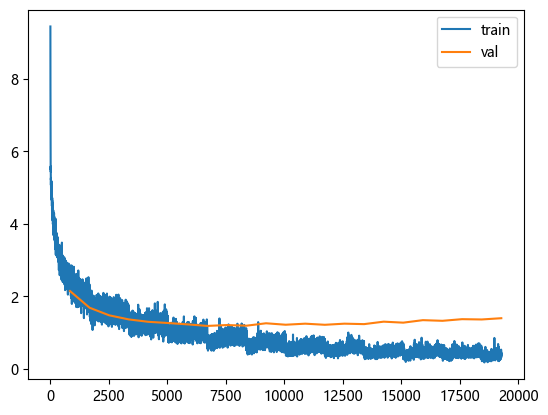

In [19]:
# 从 record 字典中提取训练集的 global_step 和 loss 序列，绘制训练 loss 折线图
# record["train"] 为 list[{"loss": float, "step": int}]，列表推导分别提取横纵轴数据
# label="train"：图例标签，用于区分训练/验证曲线
plt.plot(
    [i["step"] for i in record["train"]],  # 横轴：global_step（训练步数）
    [i["loss"] for i in record["train"]],  # 纵轴：每步的训练 loss 值
    label="train"
)

# 叠加验证集 loss 折线图（每隔 eval_step 步才有一个验证点，因此点数比训练曲线少）
# label="val"：图例标签
plt.plot(
    [i["step"] for i in record["val"]],  # 横轴：验证时的 global_step
    [i["loss"] for i in record["val"]],  # 纵轴：验证集平均 loss
    label="val"
)

# plt.legend()：在图中显示图例（区分 train 与 val 曲线）
plt.legend()

# plt.show()：渲染并在 Notebook 中嵌入显示图像（%matplotlib inline 模式下生效）
plt.show()

## 五、推理与翻译演示

加载最优检查点进行单句贪心解码，并绘制 **注意力热力图** 观察源-目标词对齐关系。课程目标亦可扩展 BLEU-4 等指标评估。


source: cuánto tiempo sin verte ! 
pred: take time to see you !


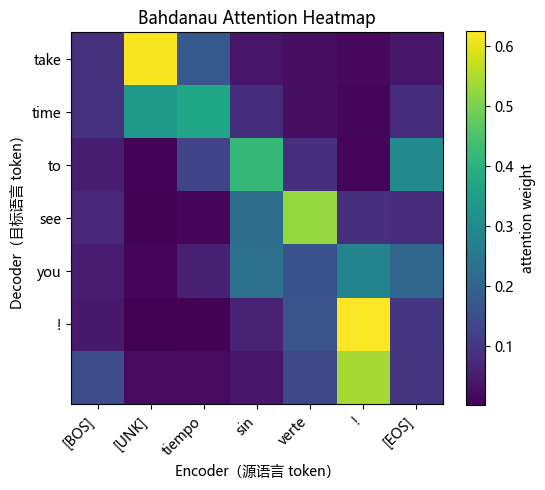

In [20]:
# 重新实例化 Seq2Seq 模型（结构与训练时完全一致）
# 注意：必须与训练时的超参数保持完全一致，否则 state_dict 的键名/张量形状不匹配会导致 RuntimeError
model = Sequence2Sequence(
    src_vocab_size=len(src_word2idx),   # int，源语言（西语）词表大小
    trg_vocab_size=len(trg_word2idx),   # int，目标语言（英语）词表大小
    dropout_de=0.6,                     # float，Decoder 层间 Dropout 概率（与训练一致）
)

# 加载训练阶段保存的最优权重文件（best.ckpt）
# torch.load(path, map_location=device)：
#   path        : str  检查点文件路径
#   map_location: device，将保存时所在的设备（可能为 GPU）映射到当前 device
# model.load_state_dict(state_dict)：
#   将加载的 state_dict（权重字典）填充到模型的各层参数中
model.load_state_dict(
    torch.load(r"model_checkpoints/1_model/1_model_best.ckpt", map_location=device)
)

# 将模型迁移到目标计算设备（GPU 或 CPU）
model = model.to(device)

# 切换到评估模式：关闭 Dropout，固定 BatchNorm 统计量（如有）
model.eval()

# 待翻译的西语原始输入句子（已按 preprocess_sentence 风格预处理：小写、标点前有空格）
raw_text = "cuánto tiempo sin verte ! "  # 英文：long time no see!

# 编码源句为整数 id 张量：
#   raw_text.split()：按空格分词 → list[str]（单条句子需再包一层 list 作为 batch）
#   add_bos=True, add_eos=True：在序列两端加上 BOS 和 EOS
#   return_mask=True：同时返回 PAD 掩码（本句无 PAD，掩码全为 0）
# encoder_inputs : Tensor[1, T_src]，int64
# attn_mask      : Tensor[1, T_src]，int64，1=PAD（此处全为 0）
encoder_inputs, attn_mask = src_tokenizer.encode(
    [raw_text.split()], add_bos=True, add_eos=True, return_mask=True
)

# 贪心解码推理：model.infer 内部自动循环直到生成 EOS 或达到 max_length
# 参数：encoder_inputs 和 attn_mask 均需迁移到 device
# pred_ids : list[int]  预测的目标 token id 序列（含 EOS）
# scores   : Tensor[1, T_src, T_dec]  各解码步对各源位置的注意力权重矩阵
pred_ids, scores = model.infer(encoder_inputs.to(device), attn_mask.to(device))

# 将预测 id 序列解码为英语字符串
# trg_tokenizer.decode([pred_ids])：输入 list[list[int]]，输出 list[str]
# [0]：取 batch 中第 0 条（也是唯一一条）解码结果
pred_text = trg_tokenizer.decode([pred_ids])

# 打印源语言（西语）与预测目标语言（英语）
print("source: {}\npred: {}".format(raw_text, pred_text[0]))

# ─── 注意力热力图可视化 ───

# scores 形状：[1, T_src, T_dec]
# .squeeze(0)：去掉 batch 维 → [T_src, T_dec]
# .cpu().numpy()：迁移到 CPU 并转为 NumPy 数组，用于 plt.imshow 显示
# .T（转置）：变为 [T_dec, T_src]
#   行 = 解码步（目标 token），列 = 源位置（源 token）
#   符合热力图的常规布局：纵轴为预测词，横轴为源词
attention_matrix = scores.squeeze(0).cpu().numpy().T

# 解码源句 token 标签（用于热力图横轴刻度）：
#   encoder_inputs.squeeze(0).tolist()：将 Tensor[1, T_src] → list[int]
#   remove_bos=False, remove_eos=False：保留 [BOS] 和 [EOS] 标签，显示完整序列
#   remove_pad=True：去掉 [PAD]（源句较短时可能有 PAD）
#   split=True：返回词列表而非拼接字符串
src_token_ids = encoder_inputs.squeeze(0).tolist()
src_tokens = src_tokenizer.decode(
    [src_token_ids],
    remove_bos=False, remove_eos=False, remove_pad=True, split=True
)[0]

# 解码目标（预测）token 标签（用于热力图纵轴刻度）：
#   去掉 [BOS]（推理时不输出 BOS）和 [EOS]（终止符通常不显示在标签中）
trg_tokens = trg_tokenizer.decode(
    [pred_ids], remove_bos=True, remove_eos=True, remove_pad=True, split=True
)[0]

# ── 字体配置（局部保险）────────────────────────────────────────────────────────
# 在绘图前再次显式设置，防止因 cell 乱序执行导致全局 rcParams 未生效。
# DejaVu Sans 不含中文字形，必须指定支持 CJK 的字体，否则中文标签渲染为方块并产生 UserWarning。
# Windows 系统内置字体优先级：微软雅黑 > 黑体 > 宋体 > 英文兜底
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'DejaVu Sans']
# axes.unicode_minus=False：修复切换为中文字体后负号（−）渲染为方块的问题
plt.rcParams['axes.unicode_minus'] = False

# 创建 Matplotlib 图像，大小根据源/目标 token 数量动态调整
# cell_size : float，每个注意力格子在图像中的边长（英寸），宽高方向使用相同值以保证正方形格子
# figsize=(width, height)：
#   width  = len(src_tokens) * cell_size：图像宽度 = 源 token 数 × 单格边长
#   height = len(trg_tokens) * cell_size：图像高度 = 目标 token 数 × 单格边长
#   两个方向使用相同的 cell_size，配合 aspect="equal"，每个注意力格子严格呈正方形
cell_size = 0.8  # float，每个格子的边长（英寸），可按需调整
fig, ax = plt.subplots(figsize=(len(src_tokens) * cell_size, len(trg_tokens) * cell_size))

# ax.imshow：以热力图方式显示注意力矩阵
#   attention_matrix : ndarray[T_dec, T_src]  注意力权重（0~1）
#   cmap="viridis"   : 颜色映射方案，颜色越亮表示注意力权重越高
#   aspect="equal"   : 强制每个数据单元格（格子）的像素宽高比为 1:1，即正方形格子
im = ax.imshow(attention_matrix, cmap="viridis", aspect="equal")

# 设置横轴（源 token）刻度与标签
ax.set_xticks(range(len(src_tokens)))
# rotation=45, ha="right"：标签旋转 45° 斜向右对齐，防止标签重叠
ax.set_xticklabels(src_tokens, rotation=45, ha="right")

# 设置纵轴（目标 token）刻度与标签
ax.set_yticks(range(len(trg_tokens)))
ax.set_yticklabels(trg_tokens)

# 设置坐标轴标题与图表标题
ax.set_xlabel("Encoder（源语言 token）")   # 横轴：源语言词
ax.set_ylabel("Decoder（目标语言 token）")  # 纵轴：生成的目标语言词
ax.set_title("Bahdanau Attention Heatmap")  # 图表标题

# 添加颜色条（右侧色阶说明），label 说明颜色含义
plt.colorbar(im, ax=ax, label="attention weight")

# 自动调整子图间距，防止标签被裁剪
plt.tight_layout()

# 渲染并在 Notebook 中嵌入显示
plt.show()

### 5.2 测试集 BLEU-4 分数评估

使用 `nltk.translate.bleu_score.corpus_bleu` 对测试集所有样本进行贪心解码推理，并计算整体 BLEU-4 分数，量化评估翻译质量。


In [21]:
# ── 导入 BLEU 计算所需函数 ────────────────────────────────────────────────────
# corpus_bleu : 语料级 BLEU，内部先汇总整个语料的 n-gram 计数再计算精确率，结果更稳定
#   list_of_references : list[list[list[str]]]
#       外层每个元素对应一条样本（与 hypotheses 等长）
#       中间层为该样本的所有参考译文（单参考时只有 1 个元素）→ list[list[str]]
#       内层为参考译文分词后的词列表 → list[str]
#   hypotheses         : list[list[str]]，每条候选译文的词列表
#   weights            : tuple，各阶 n-gram 的权重；(0.25,0.25,0.25,0.25) = BLEU-4 均等权重
#   smoothing_function : callable 或 None，零命中时的平滑策略
#   返回值             : float，[0.0, 1.0]，越高表示预测越接近参考
#
# SmoothingFunction：提供多种平滑方案，解决高阶 n-gram 零命中导致 BLEU=0 的问题
#   method1 : Add-ε(0.1) 平滑，仅对零命中阶次的分子加 epsilon=0.1，非零阶次完全不动
#             → 注意：并非 Add-1，epsilon 默认 0.1；对零命中的修正幅度较小
#   method2 : Add-1 平滑（Lin & Och 2004），对 n≥2 每阶分子+1、分母+1，一元组不动
#             → 学术论文中"Add-1 平滑"通常指此方法，有明确的论文来源
#   method4 : Chen & Cherry (2014) 指数衰减插值平滑
#             → 句级 BLEU 的推荐方法，零命中时按句长缩放平滑值，对 corpus BLEU 相对保守
#   method5 : 相邻阶次均值平滑，用 p_{n-1}/p_n/p_{n+1} 三阶均值替代 p_n
#             → 连非零阶次也会被修改，适合短句或高阶零命中频繁的语料
#   None    : 不做平滑（标准 corpus BLEU）
#             → 语料足够大时高阶零命中极少，推荐用于正式语料级评估（WMT 等比赛标准）
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


@torch.no_grad()
def collect_translations(model, dataset, src_tokenizer, trg_tokenizer, device):
    """
    对数据集做一次贪心解码推理，收集所有样本的参考译文词列表和预测译文词列表。

    推理只运行一次，后续可对同一批预测结果用不同平滑策略多次计算 BLEU，避免重复推理。

    装饰器 @torch.no_grad()：关闭自动微分图构建，节省显存并加快推理速度。

    参数
    ----
    model         : nn.Module        已加载权重的 Seq2Seq 模型
    dataset       : LangPairDataset  数据集，__getitem__ 返回 (src_text, trg_text)
    src_tokenizer : Tokenizer        源语言分词器，用于编码西语输入
    trg_tokenizer : Tokenizer        目标语言分词器，用于解码预测 id 序列
    device        : torch.device     张量所在设备（cuda 或 cpu）

    返回
    ----
    list_of_references : list[list[list[str]]]
        corpus_bleu 所需参考译文格式；每条样本为 [[word1, word2, ...]]（单参考）
    hypotheses         : list[list[str]]
        corpus_bleu 所需候选译文格式；每条样本为 [word1, word2, ...]
    """
    # 切换为评估模式：关闭 Dropout，固定 BatchNorm（如有）统计量，保证推理结果确定性
    model.eval()

    # 参考译文列表：类型 list[list[list[str]]]
    #   第一维：与 hypotheses 等长，每条样本一个元素
    #   第二维：该样本的参考集（单参考时只有 1 个元素）
    #   第三维：参考译文分词后的词列表
    list_of_references = []

    # 候选译文列表：类型 list[list[str]]，每个元素为一条预测词列表
    hypotheses = []

    # 使用 tqdm 包装数据集迭代，实时显示推理进度条
    # src_text : str，西语句子（已由 preprocess_sentence 规范化）
    # trg_text : str，英语参考译文（已由 preprocess_sentence 规范化）
    for src_text, trg_text in tqdm(dataset, desc="贪心解码推理"):

        # ── 编码源句 ──────────────────────────────────────────────────────────
        # src_text.split()  ：按空格分词 → list[str]
        # 外层 [] 包裹      ：encode 接受 batch 输入，此处 batch_size=1
        # add_bos=True      ：序列头部插入 [BOS]（id=1），对齐训练格式
        # add_eos=True      ：序列尾部追加 [EOS]（id=3），标记序列结束
        # return_mask=True  ：同时返回 PAD 掩码张量（单句无 PAD，掩码全为 0）
        # encoder_inputs    : Tensor[1, T_src]，int64，包含 BOS + 词 id + EOS
        # attn_mask         : Tensor[1, T_src]，int64，1=PAD 位，0=有效 token
        encoder_inputs, attn_mask = src_tokenizer.encode(
            [src_text.split()],
            add_bos=True,
            add_eos=True,
            return_mask=True,
        )

        # 将张量迁移到计算设备，与模型参数设备保持一致
        # .to(device)：返回位于目标 device 上的新张量，不改变原张量
        encoder_inputs = encoder_inputs.to(device)  # Tensor[1, T_src]，int64
        attn_mask      = attn_mask.to(device)        # Tensor[1, T_src]，int64

        # ── 贪心解码推理 ──────────────────────────────────────────────────────
        # model.infer：自回归生成，每步取 logits 中概率最大的 token
        #              直到生成 [EOS] 或达到 max_length 为止
        #   返回值：
        #     pred_ids : list[int]，预测目标 token id 序列
        #     _        : Tensor，各解码步注意力权重（此处不需要，用 _ 忽略）
        pred_ids, _ = model.infer(encoder_inputs, attn_mask)

        # ── 解码预测 id 序列 → 词列表 ─────────────────────────────────────────
        # trg_tokenizer.decode([pred_ids])：输入 list[list[int]]（batch=1），输出 list
        #   split=True      ：返回 list[str]（词列表），供 BLEU 使用
        #   remove_eos=True ：遇到 [EOS] 停止，结果中不含 [EOS]
        #   remove_bos=True ：跳过 [BOS]（推理时不输出 BOS，保险起见加上）
        #   remove_pad=True ：去除尾部 [PAD]（贪心解码不生成 PAD，保险起见加上）
        # [0]：取 batch 第 0 条（也是唯一一条），类型 list[str]
        pred_tokens = trg_tokenizer.decode(
            [pred_ids],
            remove_bos=True,
            remove_eos=True,
            remove_pad=True,
            split=True,
        )[0]  # list[str]，当前样本预测词列表

        # ── 收集参考译文 ──────────────────────────────────────────────────────
        # trg_text.split()：按空格分词 → list[str]
        ref_tokens = trg_text.split()  # list[str]，参考译文词列表

        # corpus_bleu 要求每条样本的参考集格式为 list[list[str]]（支持多参考）
        # 单参考时包装为只含一个元素的列表：[[word1, word2, ...]]
        list_of_references.append([ref_tokens])

        # corpus_bleu 要求候选译文格式为 list[str]
        hypotheses.append(pred_tokens)

    # 返回两个列表，供后续多次 BLEU 计算复用，避免重复推理
    return list_of_references, hypotheses  # tuple(list[list[list[str]]], list[list[str]])


def compute_bleu_all_methods(list_of_references, hypotheses):
    """
    对同一批预测结果，分别使用四种平滑策略计算 corpus BLEU-4 分数并格式化打印。

    五种策略说明
    ────────────
    无平滑（None）  : 标准 corpus BLEU，大语料推荐，与 WMT 等学术评测对齐
    method1         : Add-ε(0.1) 平滑，仅对零命中阶次的分子加 epsilon，非零阶次不动
    method2         : Add-1 平滑（Lin & Och 2004），n≥2 每阶分子/分母各 +1，一元组不动
    method4         : Chen & Cherry 指数衰减插值，句级 BLEU 推荐方法
    method5         : 相邻阶次均值平滑，连非零阶也会被修改，对短句零命中更友好

    参数
    ----
    list_of_references : list[list[list[str]]]   由 collect_translations 返回的参考译文
    hypotheses         : list[list[str]]          由 collect_translations 返回的候选译文

    返回
    ----
    dict[str, float]
        键为策略名称（str），值为对应的 BLEU-4 分数（float，[0.0, 1.0]）
    """
    # 实例化平滑函数对象，所有方法均从同一实例取出，保证内部参数一致
    # SmoothingFunction()：构造函数无参数，方法通过属性访问
    sf = SmoothingFunction()

    # 平滑策略配置表：列表元素为 (策略名称, smoothing_function 参数, 策略简述)
    # 类型：list[tuple[str, callable | None, str]]
    configs = [
        # (名称,           平滑函数,    显示描述)
        # ── 无平滑：标准学术基准，大语料下推荐 ──────────────────────────────────
        ("无平滑 (None)",   None,        "标准 corpus BLEU，WMT/ACL 学术基准，大语料推荐"),
        # ── method1：Add-ε(0.1)，仅对零命中阶次生效，非零阶次不动 ──────────────
        # epsilon 默认值为 0.1，并非 Add-1；零命中时分子变为 0+0.1，分母不变
        ("method1",         sf.method1,  "Add-ε(0.1)：仅对零命中阶次分子加 0.1，非零阶次不动"),
        # ── method2：真正的 Add-1（Lin & Och 2004）──────────────────────────────
        # 对 n≥2 每阶：分子+1、分母+1；一元组（n=1）保持原值不动
        # 学术论文中"Add-1 平滑"通常指此方法，与 method1 的 Add-ε 有本质区别
        ("method2",         sf.method2,  "Add-1（Lin & Och 2004）：n≥2 分子/分母各+1，一元组不动"),
        # ── method4：Chen & Cherry 指数衰减，按句长缩放零命中平滑值 ─────────────
        # 零命中时用 1/(2^k × k/ln(句长)) 代替 0，句长越长平滑值越小
        ("method4",         sf.method4,  "Chen & Cherry 指数衰减，按句长缩放，句级 BLEU 推荐"),
        # ── method5：相邻阶次均值，连非零阶也会被修改 ───────────────────────────
        # 用 p_{n-1}、p_n、p_{n+1} 三阶均值替代 p_n，所有阶次均受影响
        ("method5",         sf.method5,  "相邻阶次均值，连非零阶也会被拉平，适合短句语料"),
    ]

    # 用于存储各策略对应 BLEU 分数的字典
    # 类型：dict[str, float]，键为策略名，值为 corpus BLEU-4 分数
    results = {}

    # 打印表头，对齐列宽方便对比
    print("=" * 62)
    print(f"{'平滑策略':<16}  {'BLEU-4':>8}  {'说明'}")
    print("-" * 62)

    # 遍历每种配置，依次计算 corpus BLEU-4 分数
    for name, smooth_fn, desc in configs:
        # corpus_bleu：
        #   list_of_references : 参考译文列表（不变，只传引用，无额外开销）
        #   hypotheses         : 候选译文列表（不变）
        #   weights            : (0.25, 0.25, 0.25, 0.25) → BLEU-4 均等权重
        #   smoothing_function : 当前平滑策略（callable 或 None）
        #   返回值             : float，[0.0, 1.0]
        score = corpus_bleu(
            list_of_references,
            hypotheses,
            weights=(0.25, 0.25, 0.25, 0.25),  # BLEU-4 均等权重
            smoothing_function=smooth_fn,        # 当前迭代的平滑策略
        )

        # 将结果存入字典，键为策略名称，值为分数
        results[name] = score  # float，[0.0, 1.0]

        # 格式化输出：策略名左对齐 16 字符，分数右对齐保留 4 位小数，乘以 100 转为百分比格式
        # score * 100 → 转为 xx.xx% 形式，与学术论文常见的 BLEU 百分比格式对齐
        print(f"{name:<16}  {score * 100:>7.2f}%  {desc}")

    print("=" * 62)

    # 返回结果字典，供后续分析或绘图使用
    return results  # dict[str, float]


# ── 第一步：推理收集预测结果（只跑一次，节省时间）────────────────────────────
# collect_translations 返回：
#   list_of_references : list[list[list[str]]]，所有样本的参考译文
#   hypotheses         : list[list[str]]，所有样本的预测译文
# test_ds：LangPairDataset("test")，约占总样本 10%（11703 条）
list_of_references, hypotheses = collect_translations(
    model, test_ds, src_tokenizer, trg_tokenizer, device
)

# ── 第二步：用四种平滑策略分别计算 BLEU-4 分数（无需再次推理）────────────────
# compute_bleu_all_methods 返回 dict[str, float]：各策略名 → 对应 BLEU-4 分数
bleu_results = compute_bleu_all_methods(list_of_references, hypotheses)

贪心解码推理: 100%|██████████| 11703/11703 [01:39<00:00, 117.68it/s]


平滑策略                BLEU-4  说明
--------------------------------------------------------------
无平滑 (None)          31.68%  标准 corpus BLEU，WMT/ACL 学术基准，大语料推荐
method1             31.68%  Add-ε(0.1)：仅对零命中阶次分子加 0.1，非零阶次不动
method2             31.68%  Add-1（Lin & Och 2004）：n≥2 分子/分母各+1，一元组不动
method4             31.68%  Chen & Cherry 指数衰减，按句长缩放，句级 BLEU 推荐
method5             37.95%  相邻阶次均值，连非零阶也会被拉平，适合短句语料
